In [2]:
import os
import json
import pandas as pd
os.makedirs("../results", exist_ok=True)
import matplotlib.pyplot as plt
# --- Third-party libraries: numerical + plotting ---
import numpy as np                               # numerical computing (arrays, arange, hstack, etc.)
import matplotlib.pyplot as plt                  # plotting and visualization (figure, subplot, ax.plot, etc.)
# --- Standard library ---
import itertools                                 # utilities for efficient looping and combinations


# --- scikit-learn: models ---
from sklearn.tree import (
    DecisionTreeClassifier,                      # decision tree classifier
)

from sklearn.neighbors import (
    KNeighborsClassifier,                        # Nearest neighbors    
)

from sklearn.linear_model import (
    LogisticRegression,                          # linear model: Logistic Regression
)

# --- Ensemble methods ---
from sklearn.ensemble import (
    VotingClassifier,                  # ensemble voting (hard / soft)
    BaggingClassifier,                 # bootstrap aggregating
    RandomForestClassifier,            # random forests
    ExtraTreesClassifier,              # extremely randomized trees
    StackingClassifier,                # stacking ensembles
    AdaBoostClassifier,                # adaptive boosting
    GradientBoostingClassifier,        # gradient boosting
    HistGradientBoostingClassifier,
)

from tensorflow.keras.models import load_model

# --- scikit-learn: model selection / evaluation ---
from sklearn.model_selection import (
    train_test_split,                            # train / test split
    cross_val_score,                             # evaluate model with cross-validation
    RepeatedStratifiedKFold,                     # repeated stratified k-fold splitting
)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.base import clone
from copy import deepcopy

from sklearn.model_selection import GridSearchCV, StratifiedKFold
import joblib
import cv2 as cv    

### Load the data

In [14]:
x_train = np.load("../processed/X_train_norm.npy")
x_val   = np.load("../processed/X_val_norm.npy")
x_test  = np.load("../processed/X_test_norm.npy")

y_train = np.load("../processed/y_train.npy")
y_val   = np.load("../processed/y_val.npy")
y_test  = np.load("../processed/y_test.npy")

In [15]:
#Verification
print("X_train:", x_train.shape)
print("X_val:", x_val.shape)
print("X_test:", x_test.shape)

X_train: (54000, 784)
X_val: (6000, 784)
X_test: (10000, 784)


### Load 01_ensemble.json results

In [3]:
with open("../results/01_ensemble.json", "r") as f:
    ensemble_results = json.load(f)

## 0 Helper function

In [17]:
def plot_res_mod(
    data_x,
    data_y,
    weights=None,
    regressor=None,
    is_list=False,
    labels=None,
    is_data_list=False,
    data_labels=None,
    func=None,
    data_style=None,
    xlabel="X",
    ylabel="Y",
    title=None,
    save_path=None,
):
    """
    Plot data points and optionally one or more fitted lines.

    Parameters
    ----------
    data_x : array-like or list of array-like
        X-values for data points. If `is_data_list` is True, this should be a list
        where each element corresponds to one dataset.
    data_y : array-like or list of array-like
        Y-values for data points, matching the structure of `data_x`.
    weights : tuple/list or list of tuples/lists, optional
        Linear model parameters. For a single model: (bias, slope).
        For multiple models (when `is_list` is True): list of (bias, slope) pairs.
    regressor : object, optional
        Model with a `.predict(X)` method (e.g. sklearn regressor). Plotted as a line.
        Expects `predict` to accept shape (n, 1). If it accepts 1D, we fall back.
    is_list : bool, default False
        Whether `weights` contains multiple (bias, slope) pairs.
    labels : list of str, optional
        Labels for the fitted lines. Automatically generated if not provided.
    is_data_list : bool, default False
        Whether `data_x` and `data_y` contain multiple datasets.
    data_labels : list of str, optional
        Labels for the datasets. Automatically generated if not provided.
    func : callable or list of callables, optional
        Transformation applied to x-values before using the weights. For multiple
        models, should be a list of callables. Defaults to identity.
    data_style : list[list[int|float,int|float]] or list[int|float,int|float], optional
        Styling for data points as [markersize, lw].
        Defaults to [[10, 0]] (points only, no connecting line).
    xlabel : str, default "X"
        Label of the x-axis.
    ylabel : str, default "Y"
        Label of the y-axis.
    title : str, optional
        Plot title.
    save_path : str, optional
        If provided, saves the figure to this path.
    """
    import numpy as np
    import matplotlib.pyplot as plt

    xval = np.arange(0.0, 5.0, 0.01)  # domain for plotting fitted lines

    markers = ["o", "v", "s", "D", "X"]
    fig = plt.figure(figsize=(6, 6), dpi=100)
    ax = plt.subplot(111)

    # ----- data labels -----
    if data_labels is None:
        if is_data_list:
            data_labels = [f"data {i}" for i in range(1, len(data_x) + 1)]
        else:
            data_labels = ["data"]

    # ----- data style -----
    if data_style is None:
        data_style = [[10, 0] for _ in range(len(data_x) if is_data_list else 1)]

    # ----- plot data -----
    if is_data_list:
        for i in range(len(data_x)):
            ms, lw = data_style[i]
            ax.plot(
                data_x[i],
                data_y[i],
                label=data_labels[i],
                lw=lw,
                marker="o",
                markersize=ms,
            )
    else:
        ms, lw = data_style[0]
        ax.plot(
            data_x,
            data_y,
            label=data_labels[0],
            lw=lw,
            marker=markers[0],
            markersize=ms,
        )

    # ----- line labels -----
    if labels is None:
        if is_list and weights is not None:
            labels = [str(i) for i in range(1, len(weights) + 1)]
        else:
            labels = ["1"]

    # ----- functions -----
    if func is None:
        if is_list and weights is not None:
            func = [lambda x: x for _ in range(len(weights))]
        else:
            func = lambda x: x

    # ----- fitted lines from weights -----
    if weights is not None:
        if is_list:
            for i, w in enumerate(weights):
                ax.plot(
                    xval,
                    [w[1] * func[i](x) + w[0] for x in xval],
                    label=labels[i],
                    lw=3,
                )
        else:
            ax.plot(
                xval,
                [weights[1] * func(x) + weights[0] for x in xval],
                label=labels[0],
                lw=3,
            )

    # ----- fitted line from regressor -----
    if regressor is not None:
        try:
            yhat = regressor.predict(xval.reshape(-1, 1))
        except Exception:
            yhat = regressor.predict(xval)

        reg_label = labels[0] if labels is not None and len(labels) > 0 else "regressor"
        ax.plot(xval, yhat, label=reg_label, lw=3)

    ax.legend(loc="best", fancybox=True, fontsize=12)
    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)

    if title is not None:
        plt.title(title, fontsize=14)

    plt.tick_params(axis="both", which="major", labelsize=12)
    plt.grid(True)

    all_y = np.hstack(data_y) if is_data_list else np.asarray(data_y)
    y_width = all_y.max() - all_y.min()
    if y_width == 0:
        y_width = 1
    plt.ylim(all_y.min() - 0.1 * y_width, all_y.max() + 0.1 * y_width)

    all_x = np.hstack(data_x) if is_data_list else np.asarray(data_x)
    x_width = all_x.max() - all_x.min()
    if x_width == 0:
        x_width = 1
    plt.xlim(all_x.min() - 0.1 * x_width, all_x.max() + 0.1 * x_width)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

In [18]:

def evaluate_sklearn_model(model, x_test, y_test, model_name="model"):
    
    y_pred = model.predict(x_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")

    print(f"{model_name} -> Accuracy: {acc:.4f} | F1: {f1:.4f}")

    return {
        "model": model_name,
        "accuracy": acc,
        "f1_weighted": f1
    }

def ensure_cnn_input_shape(x, img_h=28, img_w=28):
    if x.ndim == 2:
        x = x.reshape(-1, img_h, img_w, 1)
    elif x.ndim == 3:
        x = np.expand_dims(x, axis=-1)
    return x

def evaluate_keras_model(model, x_test, y_test, model_name="model"):
    
    y_pred_prob = model.predict(x_test, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")

    print(f"{model_name} -> Accuracy: {acc:.4f} | F1: {f1:.4f}")

    return {
        "model": model_name,
        "accuracy": acc,
        "f1_weighted": f1
    }



def evaluate_all_models(data_name, x_test_data, y_test_data):
    global results

    # 1) evaluate all sklearn models
    for file_name, skl_model in loaded_sklearn_models.items():
        res = evaluate_sklearn_model(
            skl_model,
            x_test_data,
            y_test_data,
            model_name=f"{file_name}_{data_name}"
        )
        results.append(res)

    # 2) evaluate all keras models
    x_test_data_cnn = ensure_cnn_input_shape(x_test_data)

    for file_name, cnn_model in loaded_cnn_models.items():
        res = evaluate_keras_model(
            cnn_model,
            x_test_data_cnn,
            y_test_data,
            model_name=f"{file_name}_{data_name}"
        )
        results.append(res)

In [19]:
def rotate_image(image, rotation_angle=0, scale=1):
    height, width = image.shape
    M = cv.getRotationMatrix2D(((width - 1) / 2.0, (height - 1) / 2.0),
                               rotation_angle, scale)
    image_rotated = cv.warpAffine(np.squeeze(image), M, (width, height))

    return image_rotated

In [20]:
def plot_samples(xdata, ydata, amount=40):
    for number in range(10):
        indeces = np.random.choice(np.where(ydata == number)[0],size=amount,replace=False)
        fig = plt.figure(figsize=(20,6))
        fig.suptitle("examples for number "+str(number)+":")
        nplt = 1
        for index in indeces:
            ax = fig.add_subplot(4,10,nplt)
            ax.axis('off')
            plt.imshow(xdata[index])
            nplt += 1
    

## 1 Single Methods

### 1.1 Decision tree

In [6]:
### Using validation set
score_train = []
score_val = []

### check score on VALIDATION data
for md in range(1, 16):
    ### train model
    clf = DecisionTreeClassifier(max_depth=md, random_state=42)
    clf.fit(x_train,y_train)
    ### check score
    score_train.append(clf.score(x_train, y_train))
    score_val.append(clf.score(x_val, y_val))

    misclassified = (1 - score_val[-1]) * len(x_val)
    print("md={:02}".format(md),
          "score train: {:.6f}".format(score_train[-1]),
          "score val: {:.6f}".format(score_val[-1]),
          "misclassified:", int(misclassified))

md=01 score train: 0.198556 score val: 0.198333 misclassified: 4810
md=02 score train: 0.343130 score val: 0.338000 misclassified: 3971
md=03 score train: 0.488852 score val: 0.486167 misclassified: 3083
md=04 score train: 0.590556 score val: 0.592000 misclassified: 2448
md=05 score train: 0.675333 score val: 0.667667 misclassified: 1994
md=06 score train: 0.742185 score val: 0.734333 misclassified: 1594
md=07 score train: 0.793389 score val: 0.780667 misclassified: 1316
md=08 score train: 0.832093 score val: 0.815667 misclassified: 1106
md=09 score train: 0.870241 score val: 0.840667 misclassified: 956
md=10 score train: 0.904296 score val: 0.853667 misclassified: 877
md=11 score train: 0.932778 score val: 0.868000 misclassified: 792
md=12 score train: 0.952815 score val: 0.875667 misclassified: 745
md=13 score train: 0.968296 score val: 0.872833 misclassified: 762
md=14 score train: 0.978685 score val: 0.876333 misclassified: 742
md=15 score train: 0.985537 score val: 0.881667 miscla

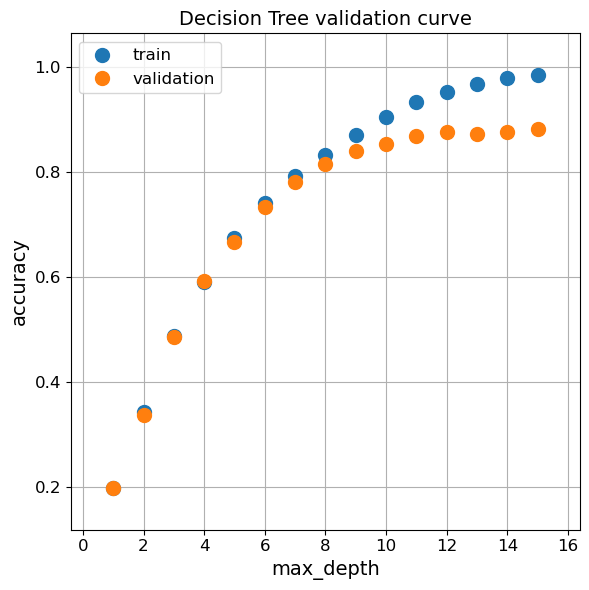

In [7]:
### plot result
max_depth = np.arange(1, len(score_train)+1, 1)
plot_res_mod(
    [max_depth, max_depth],
    [np.array(score_train), np.array(score_val)],
    is_data_list=True,
    data_labels=["train", "validation"],
    xlabel="max_depth",
    ylabel="accuracy",
    title="Decision Tree validation curve",
)

In [7]:
# Cross validation
kfold = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

for md in range(1, 20):
    clf = DecisionTreeClassifier(max_depth=md, random_state=42)
    scores = cross_val_score(clf, x_train, y_train, cv=kfold)
    ##print(md, ": {:.6f}".format(scores.mean()))
    misclassified = (1 - scores.mean()) * len(x_val)
    print(f"max_depth={md} → CV score={scores.mean():.6f} → approx misclassified={int(misclassified)}")

max_depth=1 → CV score=0.195481 → approx misclassified=4827
max_depth=2 → CV score=0.338422 → approx misclassified=3969
max_depth=3 → CV score=0.472867 → approx misclassified=3162
max_depth=4 → CV score=0.606511 → approx misclassified=2360
max_depth=5 → CV score=0.674619 → approx misclassified=1952
max_depth=6 → CV score=0.732885 → approx misclassified=1602
max_depth=7 → CV score=0.778656 → approx misclassified=1328
max_depth=8 → CV score=0.812970 → approx misclassified=1122
max_depth=9 → CV score=0.837189 → approx misclassified=976
max_depth=10 → CV score=0.852096 → approx misclassified=887
max_depth=11 → CV score=0.860615 → approx misclassified=836
max_depth=12 → CV score=0.865256 → approx misclassified=808
max_depth=13 → CV score=0.867367 → approx misclassified=795
max_depth=14 → CV score=0.868541 → approx misclassified=788
max_depth=15 → CV score=0.868304 → approx misclassified=790
max_depth=16 → CV score=0.867689 → approx misclassified=793
max_depth=17 → CV score=0.866826 → approx

Result : validation data (md = 12), crossvalidation (md=14)

In [8]:
clf = DecisionTreeClassifier(max_depth=12, random_state=42)
clf.fit(x_train,y_train)
(1-clf.score(x_val,y_val))*len(x_val)

745.9999999999998

### 1.2 Knn

In [38]:
## validation set
score_train = []
score_val = []

### vary number for NN
for k in range(1, 20):
    ### setup of model
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(x_train, y_train)
    ### check score
    score_train.append(clf.score(x_train,y_train))
    score_val.append(clf.score(x_val,y_val))
    print("k={:02}".format(k), "score train: {:.6f}".format(score_train[-1]),
          "score val: {:.6f}".format(score_val[-1]))


k=01 score train: 1.000000 score val: 0.969167
k=02 score train: 0.985556 score val: 0.961833
k=03 score train: 0.986537 score val: 0.971333
k=04 score train: 0.982481 score val: 0.967333
k=05 score train: 0.981537 score val: 0.968333
k=06 score train: 0.978981 score val: 0.966000
k=07 score train: 0.978074 score val: 0.966167
k=08 score train: 0.976481 score val: 0.965833
k=09 score train: 0.975315 score val: 0.966500
k=10 score train: 0.973963 score val: 0.965167
k=11 score train: 0.973000 score val: 0.964333
k=12 score train: 0.971741 score val: 0.963667
k=13 score train: 0.971259 score val: 0.963833
k=14 score train: 0.970500 score val: 0.962833
k=15 score train: 0.969796 score val: 0.963833
k=16 score train: 0.968815 score val: 0.962833
k=17 score train: 0.968204 score val: 0.962333
k=18 score train: 0.967556 score val: 0.962167
k=19 score train: 0.966926 score val: 0.961333


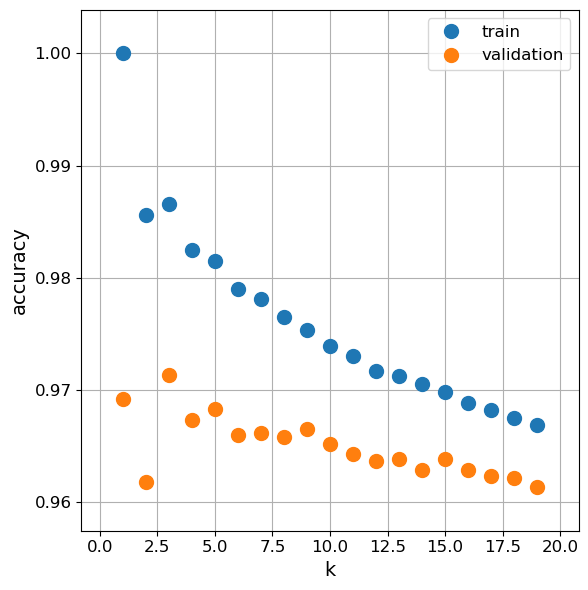

In [39]:
### plot result
nns = np.arange(1, len(score_train)+1, 1)
##plot_res([nns, nns], [np.array(score_train), np.array(score_val)], is_data_list=True)
plot_res_mod(
    [nns, nns],
    [score_train, score_val],
    is_data_list=True,
    data_labels=["train", "validation"],
    xlabel="k",
    ylabel="accuracy"
)

In [8]:
# cross validation
kfold = RepeatedStratifiedKFold(n_splits=5, n_repeats=5)

for k in range(1, 20):
    clf = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(clf, x_train, y_train, cv=kfold)
    print('k {:02}'.format(k), ": {:.6f}".format(scores.mean()))


k 01 : 0.970622
k 02 : 0.964085
k 03 : 0.970915
k 04 : 0.968904
k 05 : 0.969267
k 06 : 0.968500
k 07 : 0.967730
k 08 : 0.966678
k 09 : 0.966237
k 10 : 0.965533
k 11 : 0.965052
k 12 : 0.964274
k 13 : 0.963756
k 14 : 0.962874
k 15 : 0.962026
k 16 : 0.961696
k 17 : 0.961170
k 18 : 0.960326
k 19 : 0.959837
k 20 : 0.959456
k 21 : 0.958885
k 22 : 0.958189
k 23 : 0.957763
k 24 : 0.956989
k 25 : 0.956770
k 26 : 0.955881
k 27 : 0.955337
k 28 : 0.955456
k 29 : 0.954404
k 30 : 0.953774
k 31 : 0.953244
k 32 : 0.952648
k 33 : 0.952222
k 34 : 0.951874
k 35 : 0.951526
k 36 : 0.951230
k 37 : 0.950819
k 38 : 0.950426
k 39 : 0.949959
k 40 : 0.949289


validation set gives = 3, cross validation gives = 3 also

In [12]:
clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(x_train,y_train)
(1-clf.score(x_val,y_val))*len(x_val)

171.99999999999972

### 1.3 Logistic regression

In [13]:
### setup of LogReg model
clf = LogisticRegression(max_iter=1000)
clf.fit(x_train,y_train)
(1-clf.score(x_val,y_val))*len(x_val)

469.0000000000003

### 1.4 Compare all 3 models 

In [13]:
clf1 = DecisionTreeClassifier(max_depth=12, random_state=42)
clf2 = KNeighborsClassifier(n_neighbors=3)
clf3 = LogisticRegression(max_iter=1000)

clf1.fit(x_train,y_train)
clf2.fit(x_train,y_train)
clf3.fit(x_train,y_train)

print((1-clf1.score(x_val,y_val))*len(x_val))
print((1-clf2.score(x_val,y_val))*len(x_val))
print((1-clf3.score(x_val,y_val))*len(x_val))

745.9999999999998
171.99999999999972
469.0000000000003


# Ensemble methods

# 1 Voting Classifier

## 1.1 Hard Voting

In [7]:
estimators = [('tree', clf1), ('kNN', clf2), ('LR', clf3)]

In [8]:
### hard 
names = [e[0] for e in estimators]

mclf = VotingClassifier(
    estimators=estimators,
    voting="hard"
)

mclf.fit(x_train, y_train)

score = mclf.score(x_val, y_val)
misclassified = int((1 - score) * len(x_val))

print(f"methods: {names} | misclassified: {misclassified} | score: {score:.6f}")

methods: ['tree', 'kNN', 'LR'] | misclassified: 265 | score: 0.955833


## 1.2 Soft Voting

In [9]:
### soft 
for num_methods in range(1, 4):
    for sub_est in itertools.combinations(range(3), num_methods):

        selected_estimators = [estimators[i] for i in sub_est]
        names = [estimators[i][0] for i in sub_est]

        mclf = VotingClassifier(
            estimators=selected_estimators,
            voting="soft"
        )

        mclf.fit(x_train, y_train)

        score = mclf.score(x_val, y_val)
        misclassified = int((1 - score) * len(x_val))

        print(f"methods: {names} | wrong samples: {misclassified} | score: {score:.6f}")

methods: ['tree'] | wrong samples: 745 | score: 0.875667
methods: ['kNN'] | wrong samples: 171 | score: 0.971333
methods: ['LR'] | wrong samples: 469 | score: 0.921833
methods: ['tree', 'kNN'] | wrong samples: 338 | score: 0.943500
methods: ['tree', 'LR'] | wrong samples: 588 | score: 0.901833
methods: ['kNN', 'LR'] | wrong samples: 194 | score: 0.967500
methods: ['tree', 'kNN', 'LR'] | wrong samples: 234 | score: 0.961000


## 1.3 Weighted Soft Voting

In [14]:
### weighted 
weight_sets = [
    [1,3,2],
    [1,4,2],
    [1,5,3]
]
for w in weight_sets:
    
    mclf = VotingClassifier(
        estimators=estimators,
        voting="soft",
        weights=w
    )

    mclf.fit(x_train,y_train)

    score = mclf.score(x_val,y_val)
    misclassified = int((1-score)*len(x_val))

    print(f"weights: {w} | wrong samples: {misclassified} | score: {score:.6f}")

weights: [1, 3, 2] | wrong samples: 171 | score: 0.971333
weights: [1, 4, 2] | wrong samples: 169 | score: 0.971833
weights: [1, 5, 3] | wrong samples: 174 | score: 0.971000


# 2 Bagging

## 2.1 Bagging: Decision tree

In [35]:
#n_estimators=50 (random boostrap)
for md in range(1, 20):
    clf = DecisionTreeClassifier(max_depth=md, random_state=42)
    mclf = BaggingClassifier(estimator=clf,n_estimators=50, random_state=42)
    mclf.fit(x_train, y_train)
    
    misclassified = (1-mclf.score(x_val,y_val))*len(x_val)
    print(f"max_depth={md} → misclassified: {misclassified:.0f} → score: {mclf.score(x_val,y_val):.4f}")


max_depth=1 → misclassified: 3853 → score: 0.3578
max_depth=2 → misclassified: 3472 → score: 0.4213
max_depth=3 → misclassified: 2476 → score: 0.5873
max_depth=4 → misclassified: 1780 → score: 0.7033
max_depth=5 → misclassified: 1318 → score: 0.7803
max_depth=6 → misclassified: 970 → score: 0.8383
max_depth=7 → misclassified: 733 → score: 0.8778
max_depth=8 → misclassified: 596 → score: 0.9007
max_depth=9 → misclassified: 472 → score: 0.9213
max_depth=10 → misclassified: 387 → score: 0.9355
max_depth=11 → misclassified: 344 → score: 0.9427
max_depth=12 → misclassified: 313 → score: 0.9478
max_depth=13 → misclassified: 285 → score: 0.9525
max_depth=14 → misclassified: 284 → score: 0.9527
max_depth=15 → misclassified: 276 → score: 0.9540
max_depth=16 → misclassified: 276 → score: 0.9540
max_depth=17 → misclassified: 268 → score: 0.9553
max_depth=18 → misclassified: 277 → score: 0.9538
max_depth=19 → misclassified: 270 → score: 0.9550


## 2.2 Bagging: KNN

In [37]:
### setup of kNNs with varying number of neighbors
for k in [1,3,5,15]:
    clf = KNeighborsClassifier(n_neighbors=k)
    mclf = BaggingClassifier(estimator=clf,n_estimators=50, random_state=42)
    mclf.fit(x_train, y_train)
    
    misclassified = (1-mclf.score(x_val,y_val))*len(x_val)
    print(f"max_depth={k} → misclassified: {misclassified:.0f} → score: {mclf.score(x_val,y_val):.4f}")

max_depth=1 → misclassified: 184 → score: 0.9693
max_depth=3 → misclassified: 166 → score: 0.9723
max_depth=5 → misclassified: 182 → score: 0.9697
max_depth=15 → misclassified: 214 → score: 0.9643


## 2.3 Bagging (__only__ on Decision Tree) + Voting

Bagging __only__ on Decision Tree :

In [11]:
clf1 = DecisionTreeClassifier(max_depth=12, random_state=42)
clf2 = KNeighborsClassifier(n_neighbors=3)
clf3 = LogisticRegression(max_iter=1000)

n_estimators = 50
mclf1 = BaggingClassifier(estimator=clf1, n_estimators=n_estimators, random_state=42)
mclf1.fit(x_train, y_train)
misclassified = (1-mclf1.score(x_val,y_val))*len(x_val)
print(f"Tree → misclassified: {misclassified:.0f} → score: {mclf1.score(x_val,y_val):.4f}")

clf2.fit(x_train, y_train)
misclassified = (1-clf2.score(x_val,y_val))*len(x_val)
print(f"KNN → misclassified: {misclassified:.0f} → score: {clf2.score(x_val,y_val):.4f}")

clf3.fit(x_train, y_train)
misclassified = (1-clf3.score(x_val,y_val))*len(x_val)
print(f"LR → misclassified: {misclassified:.0f} → score: {clf3.score(x_val,y_val):.4f}")


Tree → misclassified: 313 → score: 0.9478
KNN → misclassified: 172 → score: 0.9713
LR → misclassified: 469 → score: 0.9218


### 2.3.1 Bagging + Soft Voting

In [15]:
estimators = [('bagging_tree', mclf1), ('kNN', clf2), ('LR', clf3)]

In [16]:
### soft 
for num_methods in range(1, 4):
    for sub_est in itertools.combinations(range(3), num_methods):

        selected_estimators = [estimators[i] for i in sub_est]
        names = [estimators[i][0] for i in sub_est]

        mclf = VotingClassifier(
            estimators=selected_estimators,
            voting="soft"
        )

        mclf.fit(x_train, y_train)

        score = mclf.score(x_val, y_val)
        misclassified = int((1 - score) * len(x_val))

        print(f"methods: {names} | wrong samples: {misclassified} | score: {score:.6f}")

methods: ['bagging_tree'] | wrong samples: 313 | score: 0.947833
methods: ['kNN'] | wrong samples: 171 | score: 0.971333
methods: ['LR'] | wrong samples: 469 | score: 0.921833
methods: ['bagging_tree', 'kNN'] | wrong samples: 161 | score: 0.973167
methods: ['bagging_tree', 'LR'] | wrong samples: 346 | score: 0.942167
methods: ['kNN', 'LR'] | wrong samples: 194 | score: 0.967500
methods: ['bagging_tree', 'kNN', 'LR'] | wrong samples: 188 | score: 0.968500


### 2.3.2 Bagging + Weighted Soft Voting

In [17]:
### weighted 
weight_sets = [
    [2,3,1],
    [2,4,1],
    [3,5,1]
]
for w in weight_sets:
    
    mclf = VotingClassifier(
        estimators=estimators,
        voting="soft",
        weights=w
    )

    mclf.fit(x_train,y_train)

    score = mclf.score(x_val,y_val)
    misclassified = int((1-score)*len(x_val))

    print(f"weights: {w} | wrong samples: {misclassified} | score: {score:.6f}")

weights: [2, 3, 1] | wrong samples: 155 | score: 0.974167
weights: [2, 4, 1] | wrong samples: 159 | score: 0.973333
weights: [3, 5, 1] | wrong samples: 157 | score: 0.973667


## 2.4 Random Forest

n_estim = 10:

In [12]:
for md in range(1, 19):
    mclf = RandomForestClassifier(n_estimators=10, max_depth=md, random_state=42)
    mclf.fit(x_train, y_train)

    print(f"max_depth={md} → misclassified: {(1-mclf.score(x_val,y_val))*len(x_val):.0f} → score: {mclf.score(x_val,y_val):.6f}")

max_depth=1 → misclassified: 3454 → score: 0.424333
max_depth=2 → misclassified: 2488 → score: 0.585333
max_depth=3 → misclassified: 1943 → score: 0.676167
max_depth=4 → misclassified: 1299 → score: 0.783500
max_depth=5 → misclassified: 1079 → score: 0.820167
max_depth=6 → misclassified: 907 → score: 0.848833
max_depth=7 → misclassified: 728 → score: 0.878667
max_depth=8 → misclassified: 638 → score: 0.893667
max_depth=9 → misclassified: 528 → score: 0.912000
max_depth=10 → misclassified: 447 → score: 0.925500
max_depth=11 → misclassified: 398 → score: 0.933667
max_depth=12 → misclassified: 384 → score: 0.936000
max_depth=13 → misclassified: 375 → score: 0.937500
max_depth=14 → misclassified: 345 → score: 0.942500
max_depth=15 → misclassified: 353 → score: 0.941167
max_depth=16 → misclassified: 337 → score: 0.943833
max_depth=17 → misclassified: 346 → score: 0.942333
max_depth=18 → misclassified: 343 → score: 0.942833


n_estim = 50:

In [22]:
for md in range(1, 19):
    mclf = RandomForestClassifier(n_estimators=50, max_depth=md, random_state=42)
    mclf.fit(x_train, y_train)

    print(f"max_depth={md} → misclassified: {(1-mclf.score(x_val,y_val))*len(x_val):.0f} → score: {mclf.score(x_val,y_val):.6f}")

max_depth=1 → misclassified: 3066 → score: 0.489000
max_depth=2 → misclassified: 2260 → score: 0.623333
max_depth=3 → misclassified: 1757 → score: 0.707167
max_depth=4 → misclassified: 1159 → score: 0.806833
max_depth=5 → misclassified: 892 → score: 0.851333
max_depth=6 → misclassified: 723 → score: 0.879500
max_depth=7 → misclassified: 557 → score: 0.907167
max_depth=8 → misclassified: 487 → score: 0.918833
max_depth=9 → misclassified: 417 → score: 0.930500
max_depth=10 → misclassified: 344 → score: 0.942667
max_depth=11 → misclassified: 311 → score: 0.948167
max_depth=12 → misclassified: 273 → score: 0.954500
max_depth=13 → misclassified: 261 → score: 0.956500
max_depth=14 → misclassified: 251 → score: 0.958167
max_depth=15 → misclassified: 237 → score: 0.960500
max_depth=16 → misclassified: 227 → score: 0.962167
max_depth=17 → misclassified: 220 → score: 0.963333
max_depth=18 → misclassified: 211 → score: 0.964833


n_estim = 100

In [13]:
for md in range(1, 19):
    mclf = RandomForestClassifier(n_estimators=100, max_depth=md, random_state=42)
    mclf.fit(x_train, y_train)

    print(f"max_depth={md} → misclassified: {(1-mclf.score(x_val,y_val))*len(x_val):.0f} → score: {mclf.score(x_val,y_val):.6f}")

max_depth=1 → misclassified: 2892 → score: 0.518000
max_depth=2 → misclassified: 2153 → score: 0.641167
max_depth=3 → misclassified: 1656 → score: 0.724000
max_depth=4 → misclassified: 1106 → score: 0.815667
max_depth=5 → misclassified: 890 → score: 0.851667
max_depth=6 → misclassified: 674 → score: 0.887667
max_depth=7 → misclassified: 545 → score: 0.909167
max_depth=8 → misclassified: 470 → score: 0.921667
max_depth=9 → misclassified: 400 → score: 0.933333
max_depth=10 → misclassified: 339 → score: 0.943500
max_depth=11 → misclassified: 305 → score: 0.949167
max_depth=12 → misclassified: 265 → score: 0.955833
max_depth=13 → misclassified: 244 → score: 0.959333
max_depth=14 → misclassified: 234 → score: 0.961000
max_depth=15 → misclassified: 218 → score: 0.963667
max_depth=16 → misclassified: 212 → score: 0.964667
max_depth=17 → misclassified: 209 → score: 0.965167
max_depth=18 → misclassified: 204 → score: 0.966000


n_estim = 1000:

In [14]:
for md in range(1, 19):
    mclf = RandomForestClassifier(n_estimators=1000, max_depth=md, random_state=42)
    mclf.fit(x_train, y_train)

    print(f"max_depth={md} → misclassified: {(1-mclf.score(x_val,y_val))*len(x_val):.0f} → score: {mclf.score(x_val,y_val):.6f}")

max_depth=1 → misclassified: 2754 → score: 0.541000
max_depth=2 → misclassified: 2186 → score: 0.635667
max_depth=3 → misclassified: 1499 → score: 0.750167
max_depth=4 → misclassified: 1089 → score: 0.818500
max_depth=5 → misclassified: 836 → score: 0.860667
max_depth=6 → misclassified: 653 → score: 0.891167
max_depth=7 → misclassified: 535 → score: 0.910833
max_depth=8 → misclassified: 449 → score: 0.925167
max_depth=9 → misclassified: 381 → score: 0.936500
max_depth=10 → misclassified: 324 → score: 0.946000
max_depth=11 → misclassified: 289 → score: 0.951833
max_depth=12 → misclassified: 260 → score: 0.956667
max_depth=13 → misclassified: 245 → score: 0.959167
max_depth=14 → misclassified: 223 → score: 0.962833
max_depth=15 → misclassified: 217 → score: 0.963833
max_depth=16 → misclassified: 208 → score: 0.965333
max_depth=17 → misclassified: 193 → score: 0.967833
max_depth=18 → misclassified: 193 → score: 0.967833


## 2.5 ExtraTrees

n_estim = 10:

In [15]:
for md in range(1, 19):
    mclf = ExtraTreesClassifier(n_estimators=10, max_depth=md, random_state=42)
    mclf.fit(x_train, y_train)

    print(f"max_depth={md} → misclassified: {(1-mclf.score(x_val,y_val))*len(x_val):.0f} → score: {mclf.score(x_val,y_val):.6f}")

max_depth=1 → misclassified: 3448 → score: 0.425333
max_depth=2 → misclassified: 2787 → score: 0.535500
max_depth=3 → misclassified: 2231 → score: 0.628167
max_depth=4 → misclassified: 1726 → score: 0.712333
max_depth=5 → misclassified: 1302 → score: 0.783000
max_depth=6 → misclassified: 1075 → score: 0.820833
max_depth=7 → misclassified: 914 → score: 0.847667
max_depth=8 → misclassified: 734 → score: 0.877667
max_depth=9 → misclassified: 645 → score: 0.892500
max_depth=10 → misclassified: 546 → score: 0.909000
max_depth=11 → misclassified: 472 → score: 0.921333
max_depth=12 → misclassified: 420 → score: 0.930000
max_depth=13 → misclassified: 400 → score: 0.933333
max_depth=14 → misclassified: 391 → score: 0.934833
max_depth=15 → misclassified: 361 → score: 0.939833
max_depth=16 → misclassified: 337 → score: 0.943833
max_depth=17 → misclassified: 325 → score: 0.945833
max_depth=18 → misclassified: 324 → score: 0.946000


n_estim = 50:

In [23]:
## increase number of estimators 
for md in range(1, 19):
    mclf = ExtraTreesClassifier(n_estimators=50, max_depth=md, random_state=42)
    mclf.fit(x_train, y_train)

    print(f"max_depth={md} → misclassified: {(1-mclf.score(x_val,y_val))*len(x_val):.0f} → score: {mclf.score(x_val,y_val):.6f}")

max_depth=1 → misclassified: 3164 → score: 0.472667
max_depth=2 → misclassified: 2252 → score: 0.624667
max_depth=3 → misclassified: 1880 → score: 0.686667
max_depth=4 → misclassified: 1402 → score: 0.766333
max_depth=5 → misclassified: 1082 → score: 0.819667
max_depth=6 → misclassified: 823 → score: 0.862833
max_depth=7 → misclassified: 687 → score: 0.885500
max_depth=8 → misclassified: 569 → score: 0.905167
max_depth=9 → misclassified: 488 → score: 0.918667
max_depth=10 → misclassified: 436 → score: 0.927333
max_depth=11 → misclassified: 343 → score: 0.942833
max_depth=12 → misclassified: 326 → score: 0.945667
max_depth=13 → misclassified: 281 → score: 0.953167
max_depth=14 → misclassified: 263 → score: 0.956167
max_depth=15 → misclassified: 262 → score: 0.956333
max_depth=16 → misclassified: 237 → score: 0.960500
max_depth=17 → misclassified: 216 → score: 0.964000
max_depth=18 → misclassified: 218 → score: 0.963667


n_estim = 100:

In [16]:
## increase number of estimators 
for md in range(1, 19):
    mclf = ExtraTreesClassifier(n_estimators=100, max_depth=md, random_state=42)
    mclf.fit(x_train, y_train)

    print(f"max_depth={md} → misclassified: {(1-mclf.score(x_val,y_val))*len(x_val):.0f} → score: {mclf.score(x_val,y_val):.6f}")

max_depth=1 → misclassified: 3020 → score: 0.496667
max_depth=2 → misclassified: 2234 → score: 0.627667
max_depth=3 → misclassified: 1848 → score: 0.692000
max_depth=4 → misclassified: 1354 → score: 0.774333
max_depth=5 → misclassified: 1036 → score: 0.827333
max_depth=6 → misclassified: 797 → score: 0.867167
max_depth=7 → misclassified: 663 → score: 0.889500
max_depth=8 → misclassified: 538 → score: 0.910333
max_depth=9 → misclassified: 452 → score: 0.924667
max_depth=10 → misclassified: 400 → score: 0.933333
max_depth=11 → misclassified: 342 → score: 0.943000
max_depth=12 → misclassified: 301 → score: 0.949833
max_depth=13 → misclassified: 274 → score: 0.954333
max_depth=14 → misclassified: 254 → score: 0.957667
max_depth=15 → misclassified: 239 → score: 0.960167
max_depth=16 → misclassified: 215 → score: 0.964167
max_depth=17 → misclassified: 197 → score: 0.967167
max_depth=18 → misclassified: 202 → score: 0.966333


n_estim = 1000:

In [17]:
## increase number of estimators 
for md in range(1, 19):
    mclf = ExtraTreesClassifier(n_estimators=1000, max_depth=md, random_state=42)
    mclf.fit(x_train, y_train)

    print(f"max_depth={md} → misclassified: {(1-mclf.score(x_val,y_val))*len(x_val):.0f} → score: {mclf.score(x_val,y_val):.6f}")

max_depth=1 → misclassified: 2843 → score: 0.526167
max_depth=2 → misclassified: 2193 → score: 0.634500
max_depth=3 → misclassified: 1669 → score: 0.721833
max_depth=4 → misclassified: 1292 → score: 0.784667
max_depth=5 → misclassified: 979 → score: 0.836833
max_depth=6 → misclassified: 776 → score: 0.870667
max_depth=7 → misclassified: 621 → score: 0.896500
max_depth=8 → misclassified: 508 → score: 0.915333
max_depth=9 → misclassified: 445 → score: 0.925833
max_depth=10 → misclassified: 382 → score: 0.936333
max_depth=11 → misclassified: 333 → score: 0.944500
max_depth=12 → misclassified: 298 → score: 0.950333
max_depth=13 → misclassified: 260 → score: 0.956667
max_depth=14 → misclassified: 234 → score: 0.961000
max_depth=15 → misclassified: 212 → score: 0.964667
max_depth=16 → misclassified: 207 → score: 0.965500
max_depth=17 → misclassified: 189 → score: 0.968500
max_depth=18 → misclassified: 189 → score: 0.968500


# 3 Boosting

## 3.1 AdaBoost

In [25]:
### setup of model
n_estimators = 100

for md in [1, 2, 4, 8, 10, 12, 14]:
    clf = DecisionTreeClassifier(max_depth=md, random_state=42)
    mclf = AdaBoostClassifier(estimator=clf, n_estimators=n_estimators, random_state=42)
    mclf.fit(x_train, y_train)
    print(f"max_depth={md} → misclassified: {(1-mclf.score(x_val,y_val))*len(x_val):.0f} → score: {mclf.score(x_val,y_val):.6f}")


max_depth=1 → misclassified: 1532 → score: 0.744667
max_depth=2 → misclassified: 1111 → score: 0.814833
max_depth=4 → misclassified: 589 → score: 0.901833
max_depth=8 → misclassified: 229 → score: 0.961833
max_depth=10 → misclassified: 199 → score: 0.966833
max_depth=12 → misclassified: 188 → score: 0.968667
max_depth=14 → misclassified: 191 → score: 0.968167


Fixing n_estim =100, md=12, trying different learning_rate:

## 3.2 Gradient Boosting Classifier

In [41]:
max_dep_list = [1, 5, 8, 10, 12, 15]

for md in max_dep_list:
    clf = GradientBoostingClassifier(
        n_estimators=100,
        max_depth=md,
        random_state=42)
    clf.fit(x_train, y_train)
    score = clf.score(x_val, y_val)
    print(f"md={md} → misclassified: {(1-clf.score(x_val,y_val))*len(x_val):.0f} → score: {score:.6f}")


md=1 → misclassified: 891 → score: 0.851500
md=5 → misclassified: 214 → score: 0.964333
md=8 → misclassified: 180 → score: 0.970000
md=10 → misclassified: 189 → score: 0.968500
md=12 → misclassified: 195 → score: 0.967500
md=15 → misclassified: 216 → score: 0.964000


### Comparing Adaboost and Gradient Boosting 

Trade-off between learning_rate and n_estimators (with max-depth=12)

In [5]:
n_estimators_list = [10, 50, 100, 200]
learning_rates = [0.05, 0.1, 0.5, 1]

base_tree = DecisionTreeClassifier(max_depth=12, random_state=42)

models = {
    "AdaBoost": lambda n, lr: AdaBoostClassifier(
        estimator=base_tree,
        n_estimators=n,
        learning_rate=lr,
        random_state=42
    ),
    
    "GradientBoosting": lambda n, lr: GradientBoostingClassifier(
        n_estimators=n,
        learning_rate=lr,
        max_depth=12,
        random_state=42
    )
}

for model_name, model_func in models.items():
    for n_est in n_estimators_list:
        for lr in learning_rates:

            model = model_func(n_est, lr)
            model.fit(x_train, y_train)

            score = model.score(x_val, y_val)
            wrong = int((1 - score) * len(x_val))

            print(
                f"{model_name} | "
                f"n_estimators={n_est} | "
                f"learning_rate={lr} | "
                f"wrong samples={wrong} | "
                f"score={score:.6f}"
            )

AdaBoost | n_estimators=10 | learning_rate=0.05 | wrong samples=388 | score=0.935167
AdaBoost | n_estimators=10 | learning_rate=0.1 | wrong samples=297 | score=0.950333
AdaBoost | n_estimators=10 | learning_rate=0.5 | wrong samples=266 | score=0.955500
AdaBoost | n_estimators=10 | learning_rate=1 | wrong samples=345 | score=0.942333
AdaBoost | n_estimators=50 | learning_rate=0.05 | wrong samples=194 | score=0.967500
AdaBoost | n_estimators=50 | learning_rate=0.1 | wrong samples=169 | score=0.971667
AdaBoost | n_estimators=50 | learning_rate=0.5 | wrong samples=163 | score=0.972667
AdaBoost | n_estimators=50 | learning_rate=1 | wrong samples=211 | score=0.964833
AdaBoost | n_estimators=100 | learning_rate=0.05 | wrong samples=162 | score=0.973000
AdaBoost | n_estimators=100 | learning_rate=0.1 | wrong samples=151 | score=0.974667
AdaBoost | n_estimators=100 | learning_rate=0.5 | wrong samples=156 | score=0.974000
AdaBoost | n_estimators=100 | learning_rate=1 | wrong samples=187 | score=

## 3.3 HistGradientBoosting Classifier

In [8]:
for max_iter in [10, 50, 100, 200]:
    for lr in [0.05, 0.1, 0.5, 1]:
        hgb = HistGradientBoostingClassifier(
            learning_rate=lr,
            max_iter=max_iter,
            max_depth=12,
            random_state=42
        )
    
        hgb.fit(x_train, y_train)
    
        score = hgb.score(x_val, y_val)
        misclassified = int((1 - score) * len(x_val))
    
        print(f"max_iter={max_iter} → learning_rate: {lr} → misclassified: {misclassified} → score: {score:.6f}")

max_iter=10 → learning_rate: 0.05 → misclassified: 472 → score: 0.921333
max_iter=10 → learning_rate: 0.1 → misclassified: 412 → score: 0.931167
max_iter=10 → learning_rate: 0.5 → misclassified: 723 → score: 0.879500
max_iter=10 → learning_rate: 1 → misclassified: 1197 → score: 0.800500
max_iter=50 → learning_rate: 0.05 → misclassified: 272 → score: 0.954500
max_iter=50 → learning_rate: 0.1 → misclassified: 194 → score: 0.967500
max_iter=50 → learning_rate: 0.5 → misclassified: 723 → score: 0.879500
max_iter=50 → learning_rate: 1 → misclassified: 1272 → score: 0.787833
max_iter=100 → learning_rate: 0.05 → misclassified: 194 → score: 0.967500
max_iter=100 → learning_rate: 0.1 → misclassified: 128 → score: 0.978500
max_iter=100 → learning_rate: 0.5 → misclassified: 723 → score: 0.879500
max_iter=100 → learning_rate: 1 → misclassified: 1272 → score: 0.787833
max_iter=200 → learning_rate: 0.05 → misclassified: 139 → score: 0.976833
max_iter=200 → learning_rate: 0.1 → misclassified: 121 → s

### GridSearch on boosting models : 

__AdaBoost__ : 

In [48]:
base_tree = DecisionTreeClassifier(random_state=42)

ada = AdaBoostClassifier(
    estimator=base_tree,
    random_state=42
)

param_grid = {
    "estimator__max_depth": [1, 4, 8, 12],
    "n_estimators": [10, 50, 100, 200],
    "learning_rate": [0.05, 0.1, 0.5, 1]
}

grid_ada = GridSearchCV(
    estimator=ada,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_ada.fit(x_train, y_train)

print("Best AdaBoost parameters:", grid_ada.best_params_)
print("Best AdaBoost CV score:", grid_ada.best_score_)

Fitting 3 folds for each of 64 candidates, totalling 192 fits
Best AdaBoost parameters: {'estimator__max_depth': 12, 'learning_rate': 0.5, 'n_estimators': 200}
Best AdaBoost CV score: 0.9727037037037037


__GradientBoostingClassifier__ :

In [49]:
gb = GradientBoostingClassifier(
    random_state=42
)

param_grid = {
    "n_estimators": [10, 50, 100, 200],
    "learning_rate": [0.05, 0.1, 0.5, 1],
    "max_depth": [1, 4, 8, 12]
}

grid_gb = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_gb.fit(x_train, y_train)

print("Best GradientBoosting parameters:", grid_gb.best_params_)
print("Best GradientBoosting CV score:", grid_gb.best_score_)

Fitting 3 folds for each of 64 candidates, totalling 192 fits
Best GradientBoosting parameters: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 200}
Best GradientBoosting CV score: 0.970037037037037


__HistogramGradientBoosting__

In [14]:
hgb = HistGradientBoostingClassifier(
    random_state=42
)

param_grid = {
    "max_iter": [10, 50, 100, 200],
    "learning_rate": [0.05, 0.1, 0.5, 1],
    "max_depth": [1, 4, 8, 12]
}

grid_hgb = GridSearchCV(
    estimator=hgb,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_hgb.fit(x_train, y_train)

print("Best HistGradientBoosting parameters:", grid_hgb.best_params_)
print("Best HistGradientBoosting CV score:", grid_hgb.best_score_)

Fitting 3 folds for each of 64 candidates, totalling 192 fits
Best HistGradientBoosting parameters: {'learning_rate': 0.1, 'max_depth': 12, 'max_iter': 200}
Best HistGradientBoosting CV score: 0.9743333333333334


# 4 Stacking

__Simple Stacking__

In [18]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

models = {
    "tree": DecisionTreeClassifier(max_depth=12, random_state=42),
    "knn": KNeighborsClassifier(n_neighbors=3),
    "lr": LogisticRegression(max_iter=1000)
}

# base models + meta learner
stack_configs = [
    (["tree", "knn"], "lr"),
    (["tree", "lr"], "knn"),
    (["knn", "lr"], "tree"),
    (["tree", "knn", "lr"], "lr")
]

combo_names = []
val_scores = []
wrong_samples = []

for base_models, meta_model in stack_configs:

    estimators = [(name, models[name]) for name in base_models]
    final_estimator = models[meta_model]

    stack = StackingClassifier(
        estimators=estimators,
        final_estimator=final_estimator,
        stack_method="predict_proba",
        cv=cv
    )

    stack.fit(x_train, y_train)

    score = stack.score(x_val, y_val)
    wrong = int((1 - score) * len(x_val))

    combo_label = f"{' + '.join(base_models)} -> {meta_model}"

    combo_names.append(combo_label)
    val_scores.append(score)
    wrong_samples.append(wrong)

    print(f"methods: {base_models} -> {meta_model} | wrong samples: {wrong} | score: {score:.6f}")

methods: ['tree', 'knn'] -> lr | wrong samples: 156 | score: 0.974000
methods: ['tree', 'lr'] -> knn | wrong samples: 481 | score: 0.919833
methods: ['knn', 'lr'] -> tree | wrong samples: 181 | score: 0.969833
methods: ['tree', 'knn', 'lr'] -> lr | wrong samples: 146 | score: 0.975500


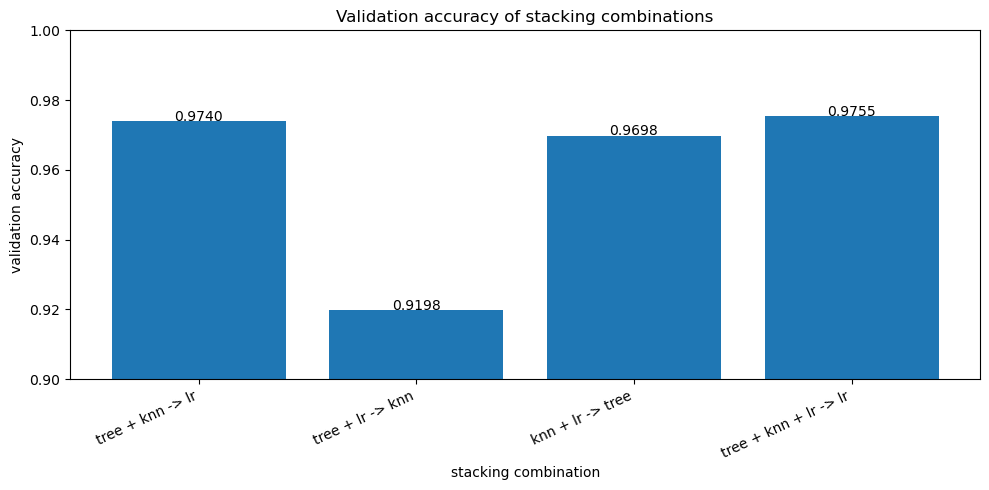

In [19]:
os.makedirs("../plot", exist_ok=True)

x = np.arange(len(combo_names))

plt.figure(figsize=(10, 5))
plt.bar(x, val_scores)
plt.xticks(x, combo_names, rotation=25, ha="right")
plt.ylabel("validation accuracy")
plt.xlabel("stacking combination")
plt.title("Validation accuracy of stacking combinations")
plt.ylim(0.9000, 1.000)

for i, v in enumerate(val_scores):
    plt.text(i, v + 0.00005, f"{v:.4f}", ha="center")

plt.tight_layout()

# save plot
plt.savefig("../plot/stacking_simple_model_val.png", dpi=300)

plt.show()

__Advanced Stacking__:

In [20]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

models = {
    "knn": KNeighborsClassifier(n_neighbors=3),
    "rf": RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        random_state=42
    ),
    "bagging_tree": BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=12, random_state=42),
        n_estimators=100,
        random_state=42
    ),
    "hgb": HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.1,
        max_depth=12,
        random_state=42
    ),
    "lr": LogisticRegression(max_iter=1000)
}

stack_combinations = [
    ["knn", "rf"],
    ["knn", "bagging_tree"],
    ["knn", "hgb"]
]

combo_names = []
val_scores = []
wrong_samples = []

for combo in stack_combinations:
    estimators = [(name, models[name]) for name in combo]

    stack = StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(max_iter=1000),
        stack_method="predict_proba",
        cv=cv
    )

    stack.fit(x_train, y_train)

    score = stack.score(x_val, y_val)
    wrong = int((1 - score) * len(x_val))

    combo_label = " + ".join(combo) + " -> lr"

    combo_names.append(combo_label)
    val_scores.append(score)
    wrong_samples.append(wrong)

    print(f"methods: {combo} -> lr | wrong samples: {wrong} | score: {score:.6f}")

methods: ['knn', 'rf'] -> lr | wrong samples: 145 | score: 0.975667
methods: ['knn', 'bagging_tree'] -> lr | wrong samples: 145 | score: 0.975667
methods: ['knn', 'hgb'] -> lr | wrong samples: 113 | score: 0.981167


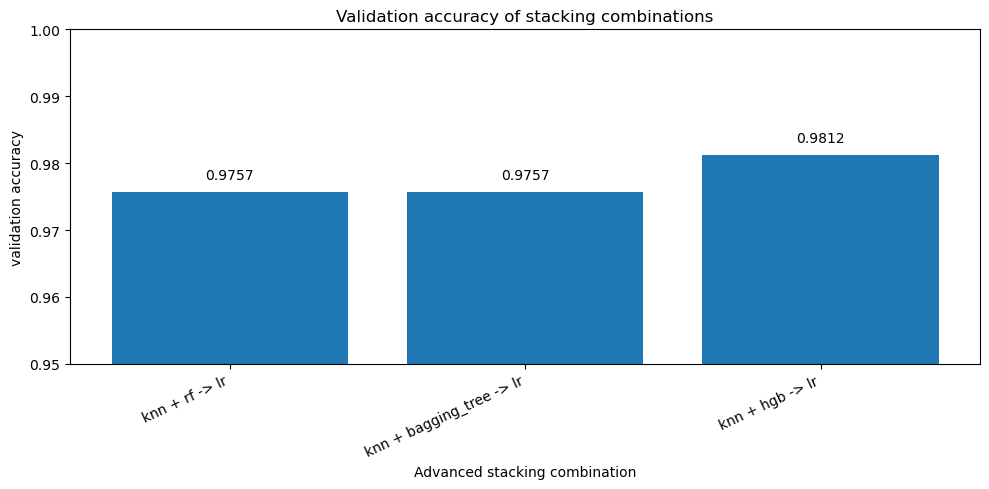

In [23]:
x = np.arange(len(combo_names))

plt.figure(figsize=(10, 5))
plt.bar(x, val_scores)
plt.xticks(x, combo_names, rotation=25, ha="right")
plt.ylabel("validation accuracy")
plt.xlabel("Advanced stacking combination")
plt.title("Validation accuracy of stacking combinations")
plt.ylim(0.95, 1.000)

for i, v in enumerate(val_scores):
    plt.text(i, v + 0.002, f"{v:.4f}", ha="center")

plt.tight_layout()

# save plot
plt.savefig("../plot/stacking_advanced_model_val.png", dpi=300)

plt.show()

# 5 Evaluation 

Final evaluation of the best models of each category : (Saving everthing in ../results/ensemble.json)

In [25]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# =========================================================
# 1) PATHS
# =========================================================
RESULTS_DIR = "../results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# =========================================================
# 2) FINAL DATASETS
# =========================================================
X_train_final = np.concatenate([x_train, x_val], axis=0)
y_train_final = np.concatenate([y_train, y_val], axis=0)

# =========================================================
# 3) BASE MODELS
# =========================================================
tree_best = DecisionTreeClassifier(
    max_depth=12,
    random_state=42
)

knn_best = KNeighborsClassifier(
    n_neighbors=3
)

lr_best = LogisticRegression(
    max_iter=1000
)

rf_best = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=42
)

bagging_tree_best = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=12, random_state=42),
    n_estimators=100,
    random_state=42
)

hgb_best = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.1,
    max_depth=12,
    random_state=42
)

# =========================================================
# 4) ENSEMBLE MODELS TO TEST
# =========================================================

# 1 — Weighted Voting + Bagging: Bagging_tree + kNN + LR, weights=[2, 3, 1]
voting_bagging_best = VotingClassifier(
    estimators=[
        ("bagging_tree", BaggingClassifier(
            estimator=DecisionTreeClassifier(max_depth=12, random_state=42),
            n_estimators=100,
            random_state=42
        )),
        ("knn", KNeighborsClassifier(n_neighbors=3)),
        ("lr", LogisticRegression(max_iter=1000))
    ],
    voting="soft",
    weights=[2, 3, 1]
)

# 4 — Simple Stacking: Tree + kNN + LR -> LR
simple_stacking_best = StackingClassifier(
    estimators=[
        ("tree", DecisionTreeClassifier(max_depth=12, random_state=42)),
        ("knn", KNeighborsClassifier(n_neighbors=3)),
        ("lr", LogisticRegression(max_iter=1000))
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method="predict_proba",
    cv=cv
)

# 5 — Advanced Stacking: kNN + HGB -> LR
advanced_stacking_best = StackingClassifier(
    estimators=[
        ("knn", KNeighborsClassifier(n_neighbors=3)),
        ("hgb", HistGradientBoostingClassifier(
            max_iter=200,
            learning_rate=0.1,
            max_depth=12,
            random_state=42
        ))
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method="predict_proba",
    cv=cv
)

final_models = {
    "Weighted Voting + Bagging": voting_bagging_best,
    "Bagging": rf_best,
    "Boosting": hgb_best,
    "Simple Stacking": simple_stacking_best,
    "Advanced Stacking": advanced_stacking_best
}

# =========================================================
# 5) HELPERS
# =========================================================
def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    return {
        "accuracy": float(acc),
        "precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "wrong_samples": int((1 - acc) * len(y_true))
    }

def safe_get_params(model):
    params = model.get_params(deep=False)
    cleaned = {}
    for k, v in params.items():
        if isinstance(v, (str, int, float, bool, type(None))):
            cleaned[k] = v
        else:
            cleaned[k] = str(v)
    return cleaned

def evaluate_model(category, model, x_train, y_train, x_val, y_val, x_train_final, y_train_final, x_test, y_test):
    """
    1) Fit on train only -> evaluate on validation
    2) Fit on train+validation -> evaluate on test
    """
    # validation experiment
    model_val = clone(model)
    model_val.fit(x_train, y_train)

    y_train_pred = model_val.predict(x_train)
    y_val_pred = model_val.predict(x_val)

    train_metrics = compute_metrics(y_train, y_train_pred)
    val_metrics = compute_metrics(y_val, y_val_pred)

    # final test experiment
    model_test = clone(model)
    model_test.fit(x_train_final, y_train_final)

    y_train_final_pred = model_test.predict(x_train_final)
    y_test_pred = model_test.predict(x_test)

    train_final_metrics = compute_metrics(y_train_final, y_train_final_pred)
    test_metrics = compute_metrics(y_test, y_test_pred)

    results = {
        "category": category,
        "model_name": type(model).__name__,
        "best_params": safe_get_params(model),
        "data_info": {
            "n_train": int(len(y_train)),
            "n_validation": int(len(y_val)),
            "n_train_plus_validation": int(len(y_train_final)),
            "n_test": int(len(y_test))
        },
        "validation_experiment": {
            "train_metrics": train_metrics,
            "validation_metrics": val_metrics,
            "scores": {
                "train_accuracy": float(train_metrics["accuracy"]),
                "validation_accuracy": float(val_metrics["accuracy"])
            }
        },
        "final_test_experiment": {
            "train_plus_validation_metrics": train_final_metrics,
            "test_metrics": test_metrics,
            "scores": {
                "train_plus_validation_accuracy": float(train_final_metrics["accuracy"]),
                "test_accuracy": float(test_metrics["accuracy"])
            }
        }
    }

    return results

# =========================================================
# 6) RUN ALL MODELS AND SAVE JSON
# =========================================================
all_results = {}

for category, model in final_models.items():
    results = evaluate_model(
        category=category,
        model=model,
        x_train=x_train,
        y_train=y_train,
        x_val=x_val,
        y_val=y_val,
        x_train_final=X_train_final,
        y_train_final=y_train_final,
        x_test=x_test,
        y_test=y_test
    )

    all_results[category] = results

with open("../results/01_ensemble.json", "w") as f:
    json.dump(all_results, f, indent=2)

print("Results saved in ../results/01_ensemble.json")

Results saved in ../results/01_ensemble.json


### Results and plot : 

In [6]:
#### Already loaded 01_ensemble.json in "ensemble_results" above
categories = []
val_accuracies = []
test_accuracies = []
wrong_test_samples = []

for category, results in ensemble_results.items():
    categories.append(category)
    val_accuracies.append(results["validation_experiment"]["scores"]["validation_accuracy"])
    test_accuracies.append(results["final_test_experiment"]["scores"]["test_accuracy"])
    wrong_test_samples.append(results["final_test_experiment"]["test_metrics"]["wrong_samples"])

In [5]:
summary_df = pd.DataFrame({
    "Category": categories,
    "Validation Accuracy": val_accuracies,
    "Test Accuracy": test_accuracies,
    "Wrong Samples (Test)": wrong_test_samples
})

print(summary_df)

                    Category  Validation Accuracy  Test Accuracy  \
0  Weighted Voting + Bagging             0.973833         0.9750   
1                    Bagging             0.955833         0.9596   
2                   Boosting             0.979667         0.9806   
3            Simple Stacking             0.975500         0.9741   
4          Advanced Stacking             0.981167         0.9836   

   Wrong Samples (Test)  
0                   250  
1                   403  
2                   193  
3                   259  
4                   163  


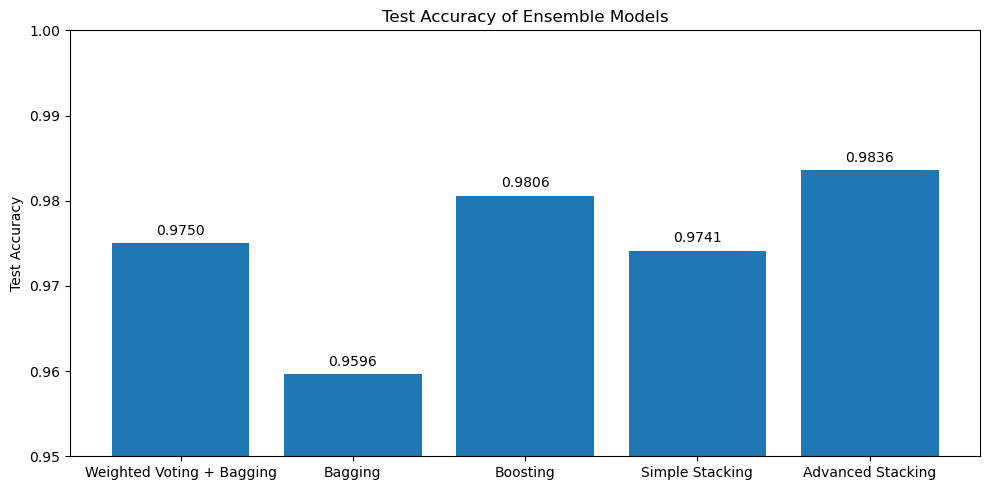

In [11]:
model_names = []
test_accuracies = []

for model_name, data in ensemble_results.items():
    
    acc = data["final_test_experiment"]["scores"]["test_accuracy"]
    
    model_names.append(model_name)
    test_accuracies.append(acc)

x = np.arange(len(model_names))

plt.figure(figsize=(10,5))

bars = plt.bar(x, test_accuracies)

plt.xticks(x, model_names, rotation=0, ha="center")

plt.ylabel("Test Accuracy")
plt.title("Test Accuracy of Ensemble Models")

plt.ylim(0.95, 1.0)

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        h+0.001,
        f"{h:.4f}",
        ha="center"
    )

plt.tight_layout()
plt.savefig("../plot/01_ensemble_test_accuracy.png", dpi=300)
plt.show()

# 6. Robustness Evaluation

In [21]:
x_train_final = np.concatenate([x_train, x_val], axis=0)
y_train_final = np.concatenate([y_train, y_val], axis=0)

In [22]:
print(x_train_final.shape, y_train_final.shape)
print(x_test.shape, y_test.shape)

(60000, 784) (60000,)
(10000, 784) (10000,)


Load CNN models:

In [23]:
### Load CNN model from ../models_cnn
models_dir = "../models"

cnn_files = [
    "model_simple.keras",
    "model_drop.keras",
    "model_drop_move.keras",
    "model_drop_full.keras",
]

loaded_cnn_models = {}

for file_name in cnn_files:
    full_path = os.path.join(models_dir, file_name)
    if os.path.exists(full_path):
        loaded_cnn_models[file_name] = load_model(full_path)
        print(f"Loaded : {full_path}")
    else:
        print(f"Not found : {full_path}")
        

Loaded : ../models/model_simple.keras
Loaded : ../models/model_drop.keras
Loaded : ../models/model_drop_move.keras
Loaded : ../models/model_drop_full.keras


Train the Stacking models (__Already done__):

In [ ]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# — Simple Stacking: Tree + kNN + LR -> LR
simple_stacking_best = StackingClassifier(
    estimators=[
        ("tree", DecisionTreeClassifier(max_depth=12, random_state=42)),
        ("knn", KNeighborsClassifier(n_neighbors=3)),
        ("lr", LogisticRegression(max_iter=1000))
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method="predict_proba",
    cv=cv
)
simple_stacking_best.fit(x_train_final, y_train_final)

# — Advanced Stacking: kNN + HGB -> LR
advanced_stacking_best = StackingClassifier(
    estimators=[
        ("knn", KNeighborsClassifier(n_neighbors=3)),
        ("hgb", HistGradientBoostingClassifier(
            max_iter=200,
            learning_rate=0.1,
            max_depth=12,
            random_state=42
        ))
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method="predict_proba",
    cv=cv
)
advanced_stacking_best.fit(x_train_final, y_train_final)

Save the training models __(Already done):__

In [ ]:
# - Save the trained models
#joblib.dump(simple_stacking_best, "../models/simple_stacking_model.joblib")
#joblib.dump(advanced_stacking_best, "../models/advanced_stacking_model.joblib")

Load the Stacking models : 

In [25]:
loaded_sklearn_models = {
    "simple_stacking_model": joblib.load("../models/simple_stacking_model.joblib"),
    "advanced_stacking_model": joblib.load("../models/advanced_stacking_model.joblib")
}

## 6.1 Clean Data

__Results clean data:__

In [26]:
results = []
evaluate_all_models("clean", x_test, y_test)

simple_stacking_model_clean -> Accuracy: 0.9741 | F1: 0.9741
advanced_stacking_model_clean -> Accuracy: 0.9836 | F1: 0.9836
model_simple.keras_clean -> Accuracy: 0.9851 | F1: 0.9851
model_drop.keras_clean -> Accuracy: 0.9906 | F1: 0.9906
model_drop_move.keras_clean -> Accuracy: 0.9860 | F1: 0.9860
model_drop_full.keras_clean -> Accuracy: 0.9896 | F1: 0.9896


## 6.2 Translation

In [27]:
### reshape it (n_sample, 28, 28)
x_test_img = x_test.reshape(-1, 28, 28)
print(x_test_img.shape)

(10000, 28, 28)


### Big shift:

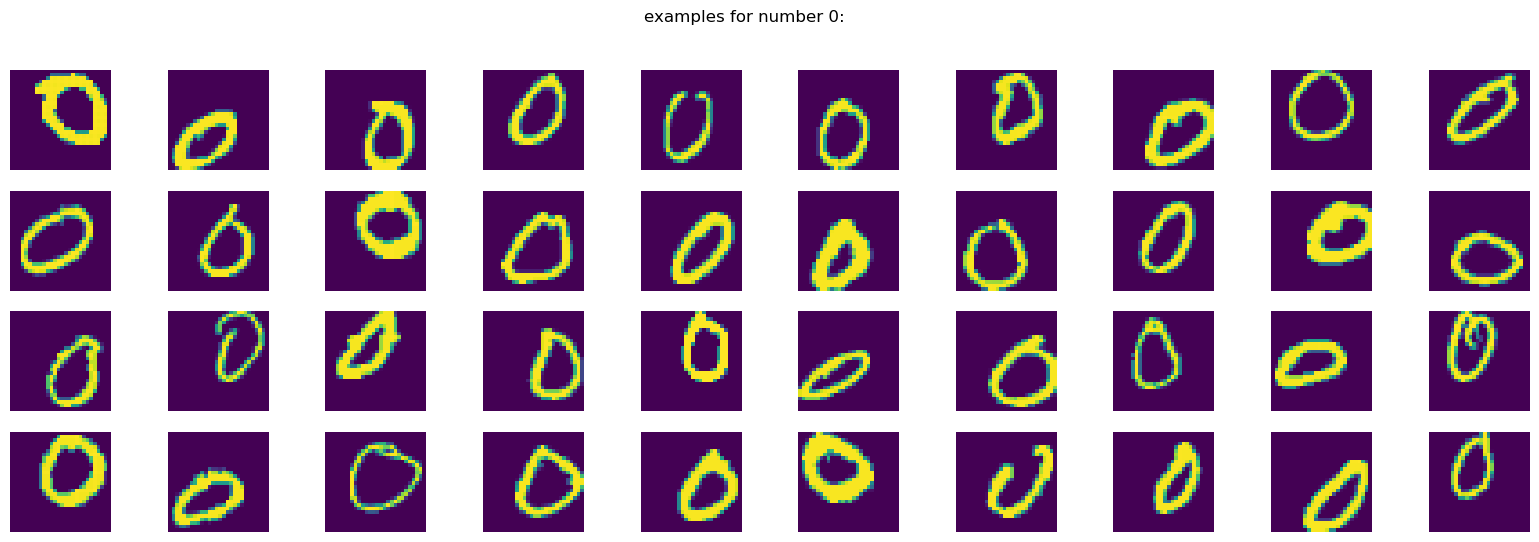

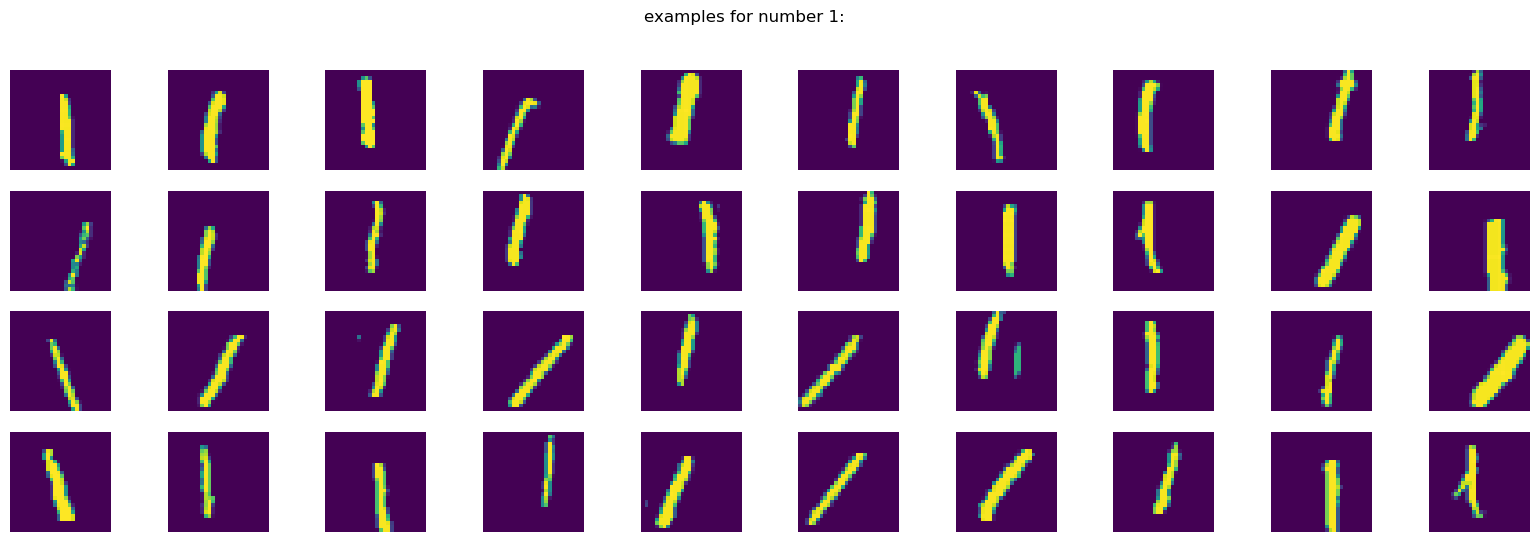

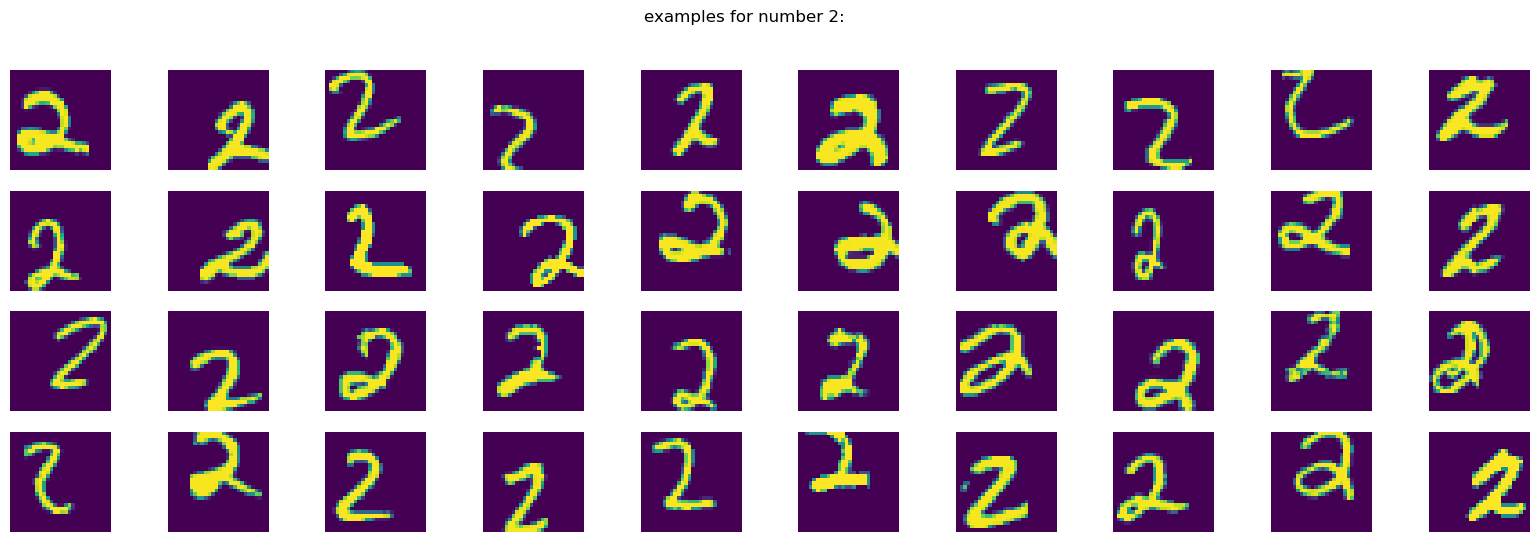

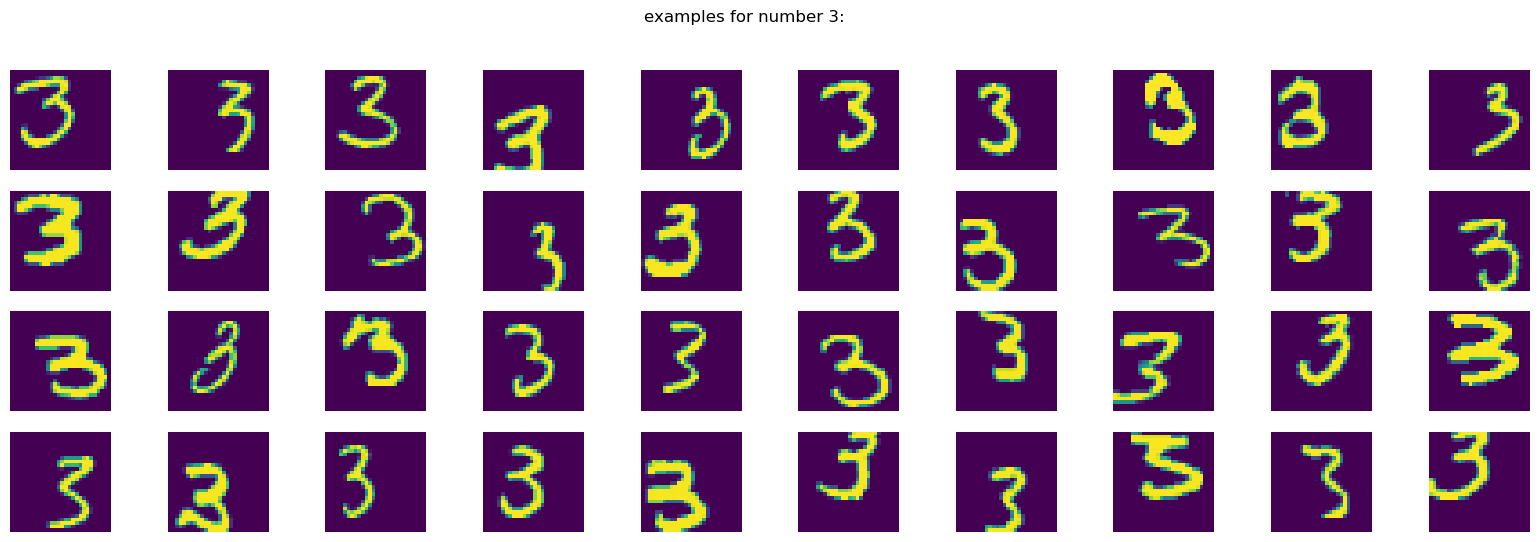

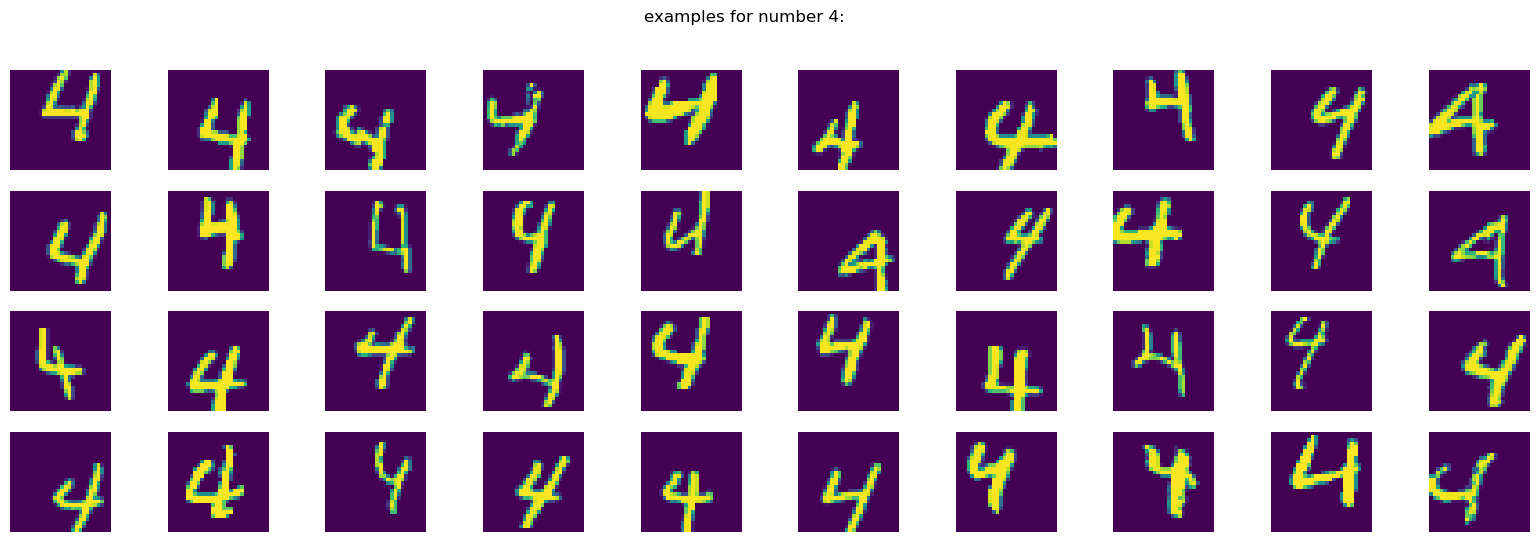

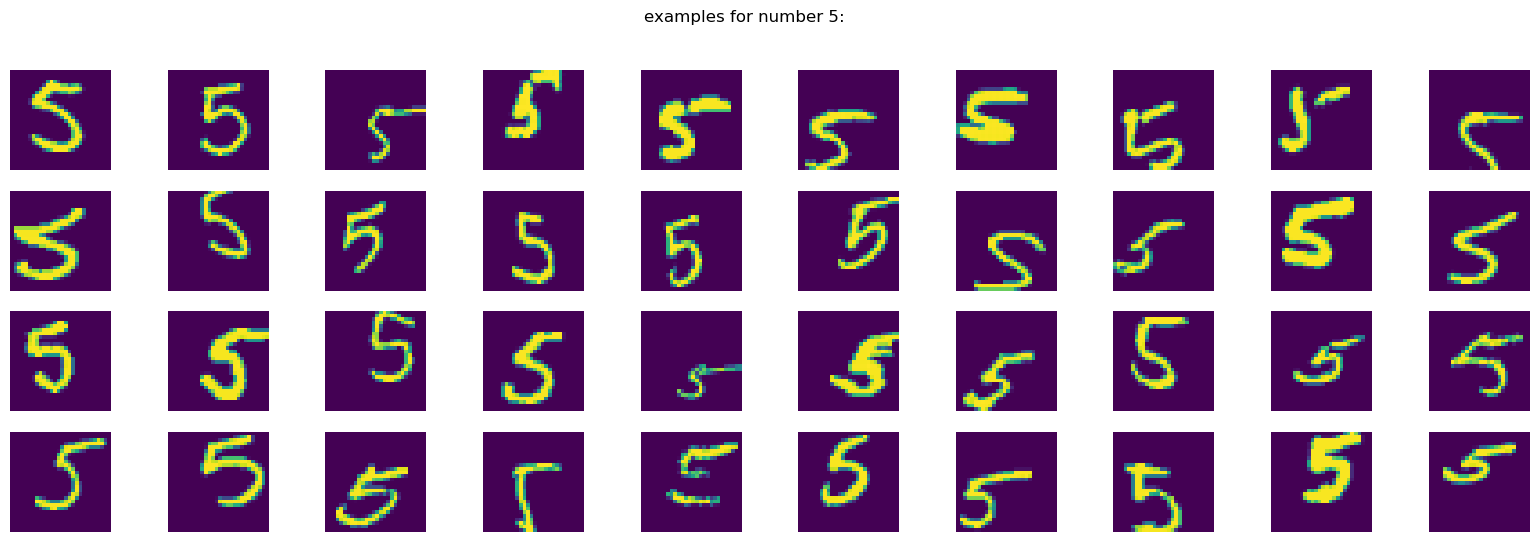

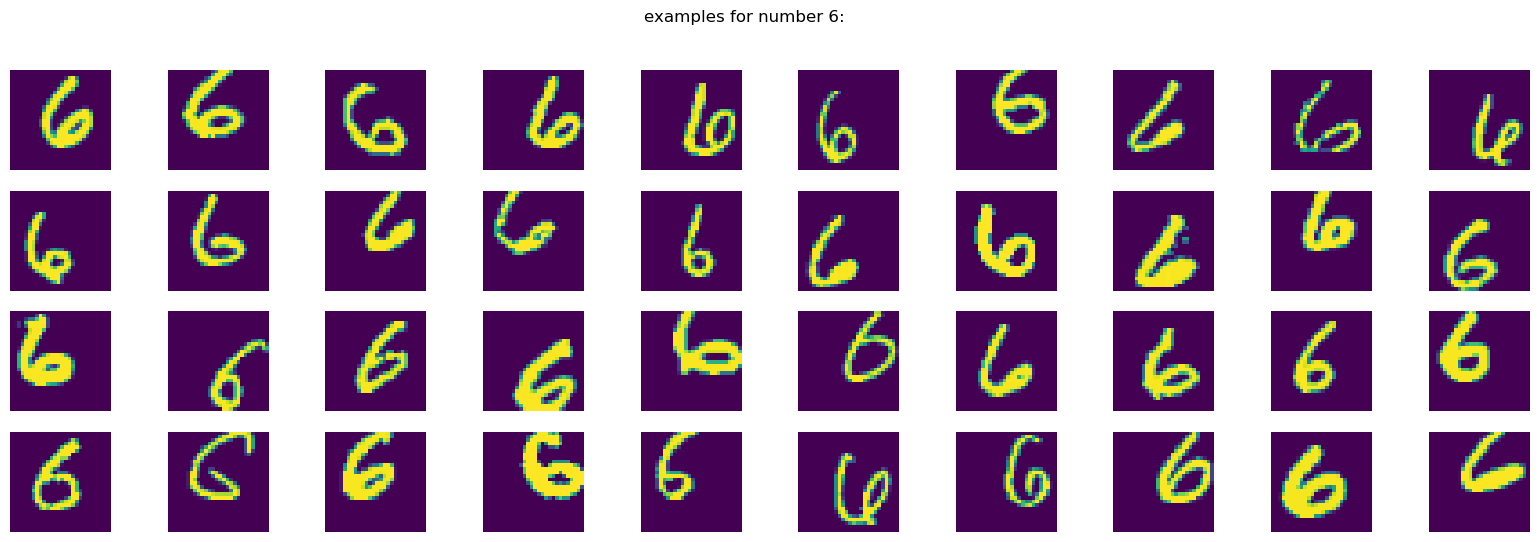

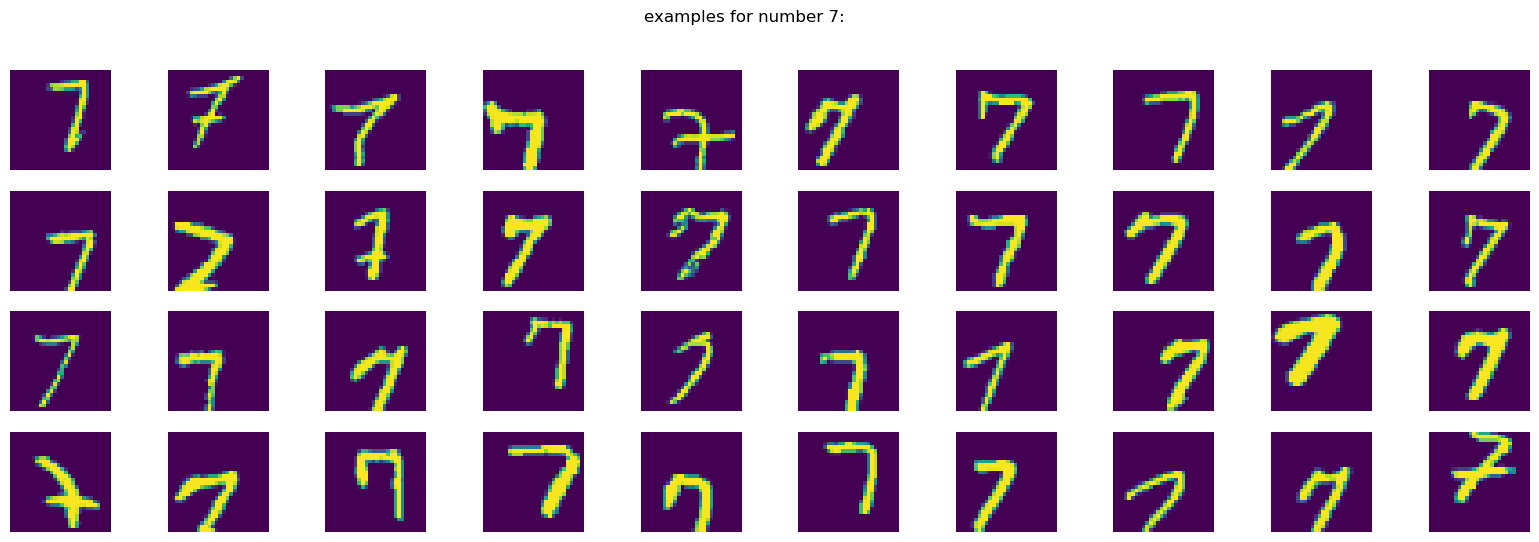

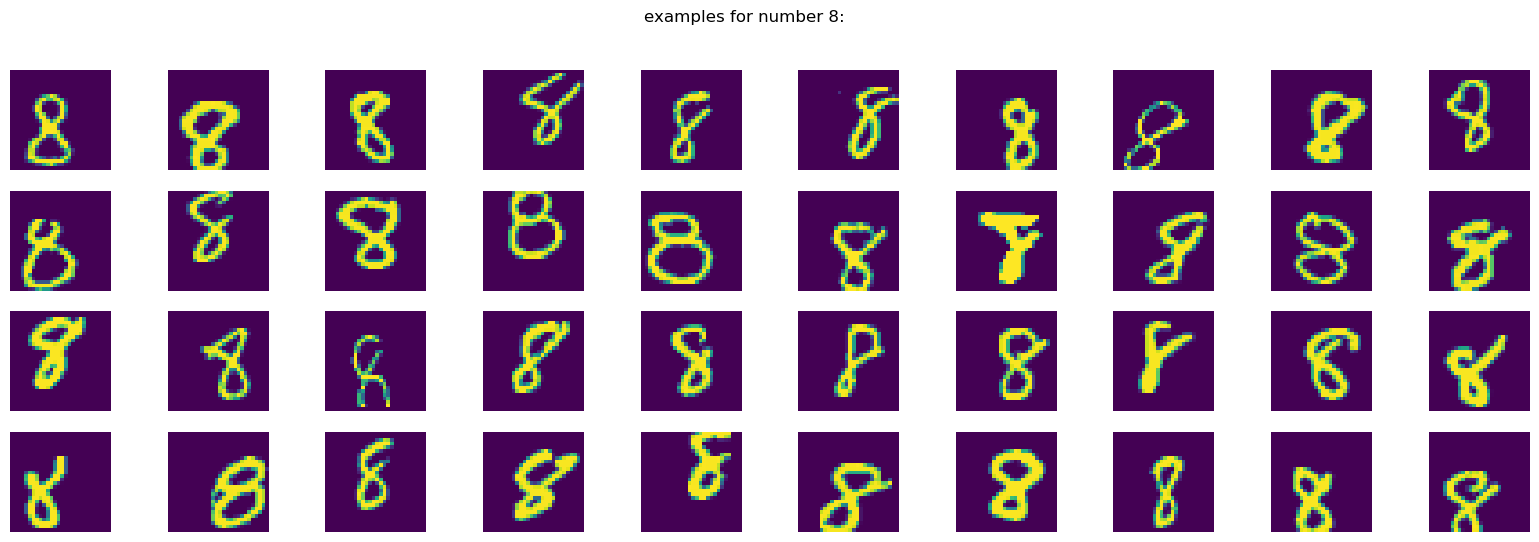

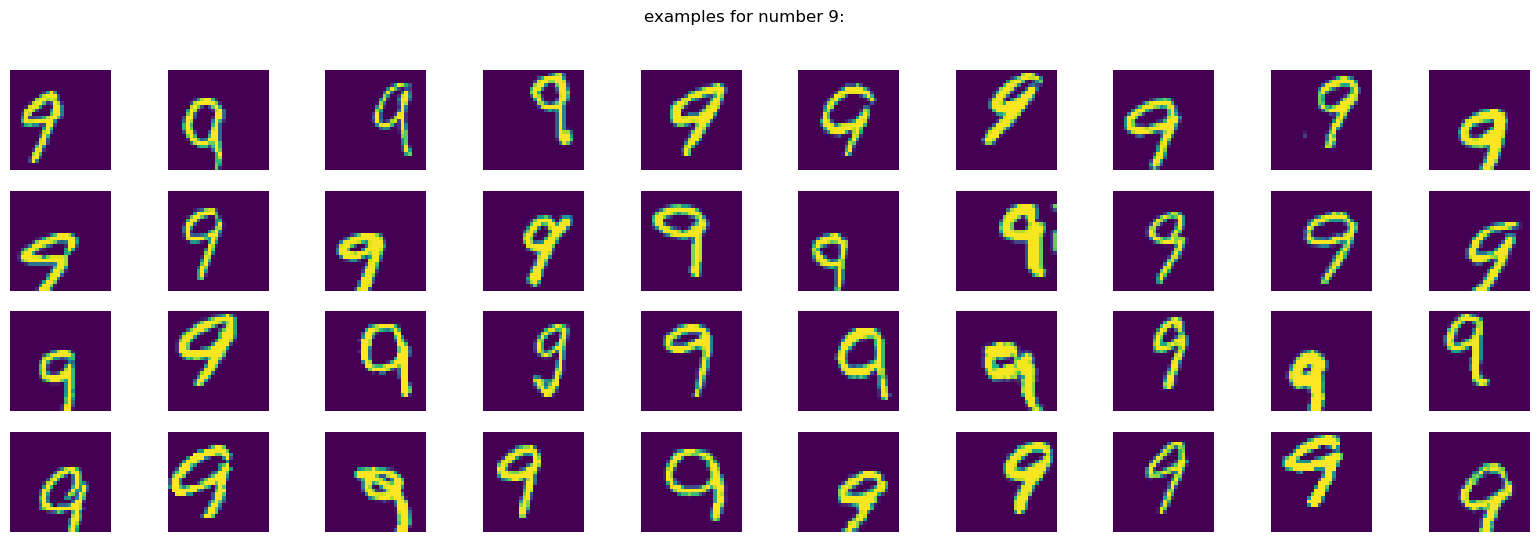

In [28]:
### -5 , 6
x_test_big_moved = np.zeros(x_test_img.shape)

for i in range(len(x_test_img)):
    shiftx = np.random.randint(-5, 6)
    shifty = np.random.randint(-5, 6)
    for j in range(max(0, shifty), min(28, 28 + shifty)):
        for k in range(max(0, shiftx), min(28, 28 + shiftx)):
            x_test_big_moved[i, j, k] = x_test_img[i, j - shifty, k - shiftx]
            
x_test_big_moved_flat = x_test_big_moved.reshape(len(x_test_big_moved), -1)

plot_samples(x_test_big_moved,y_test)

### Small shift:

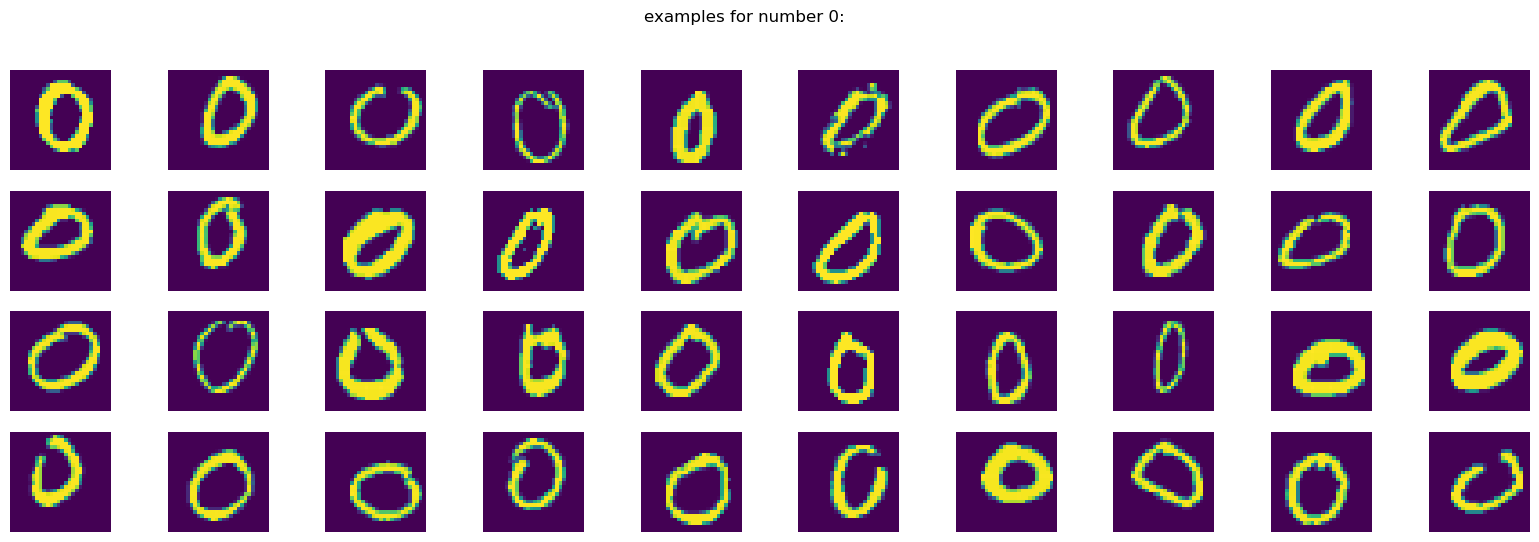

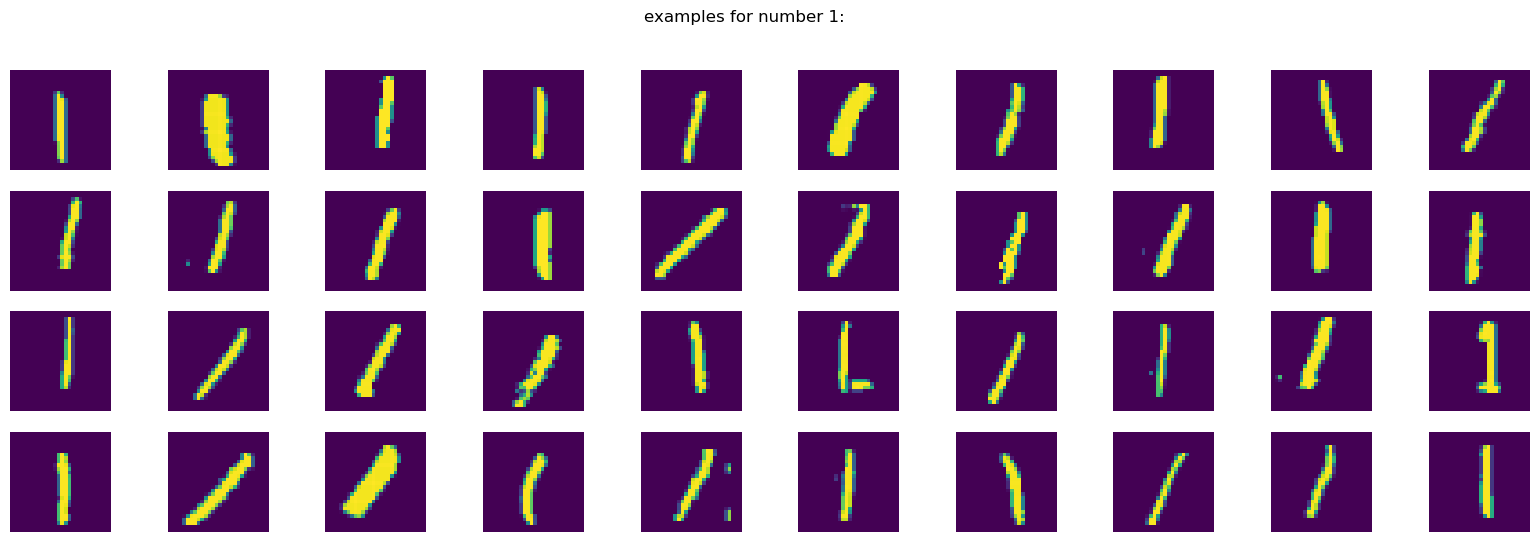

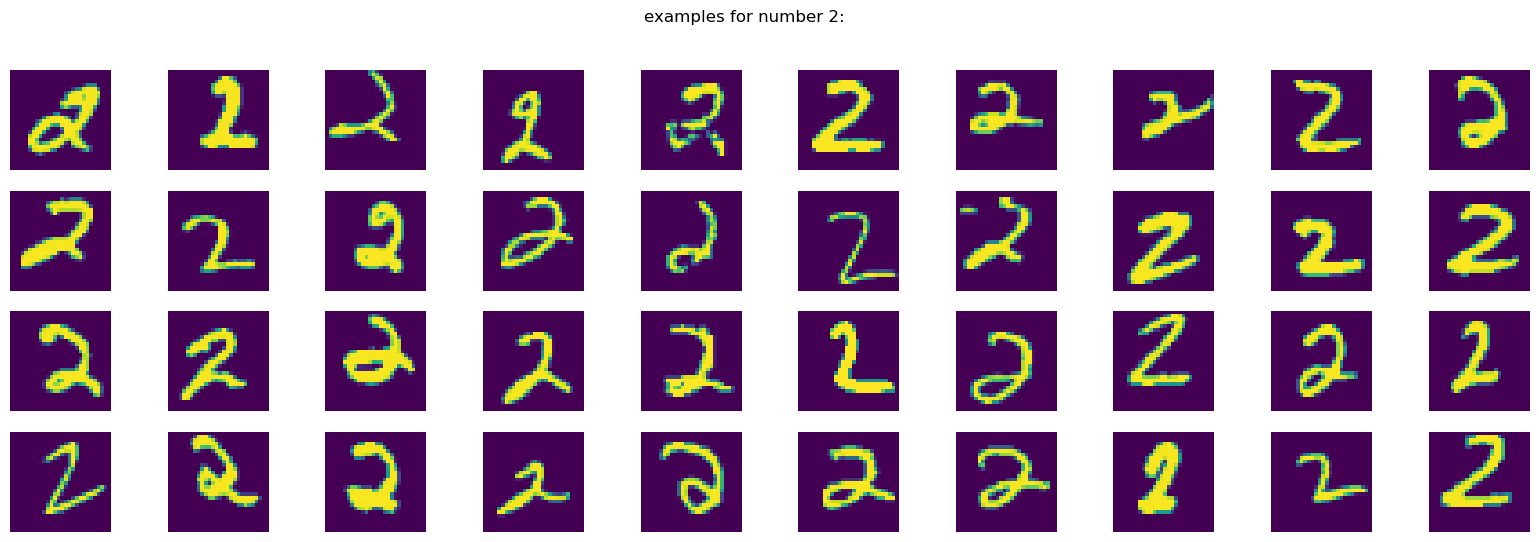

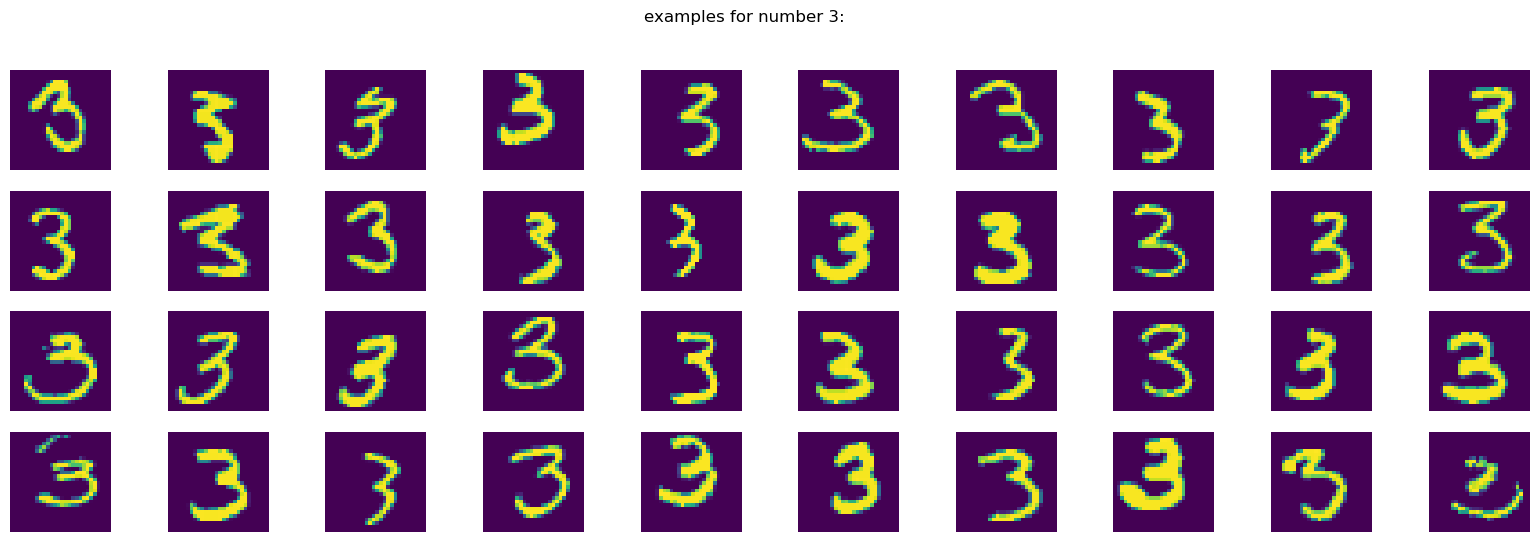

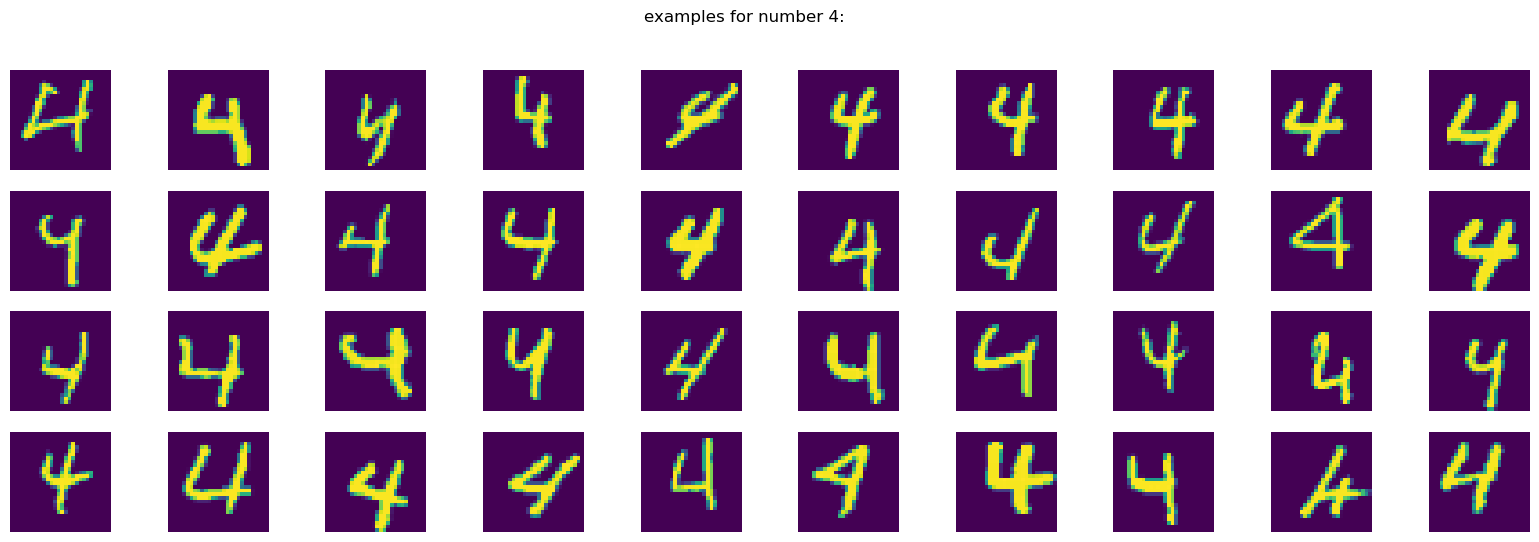

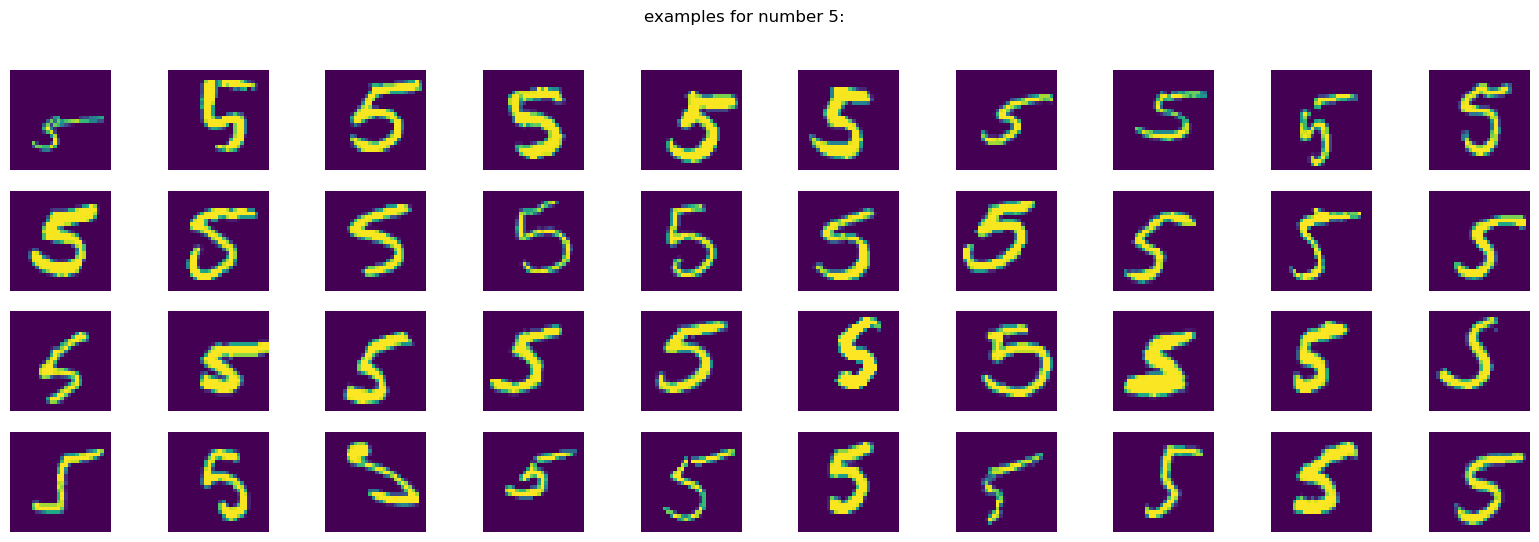

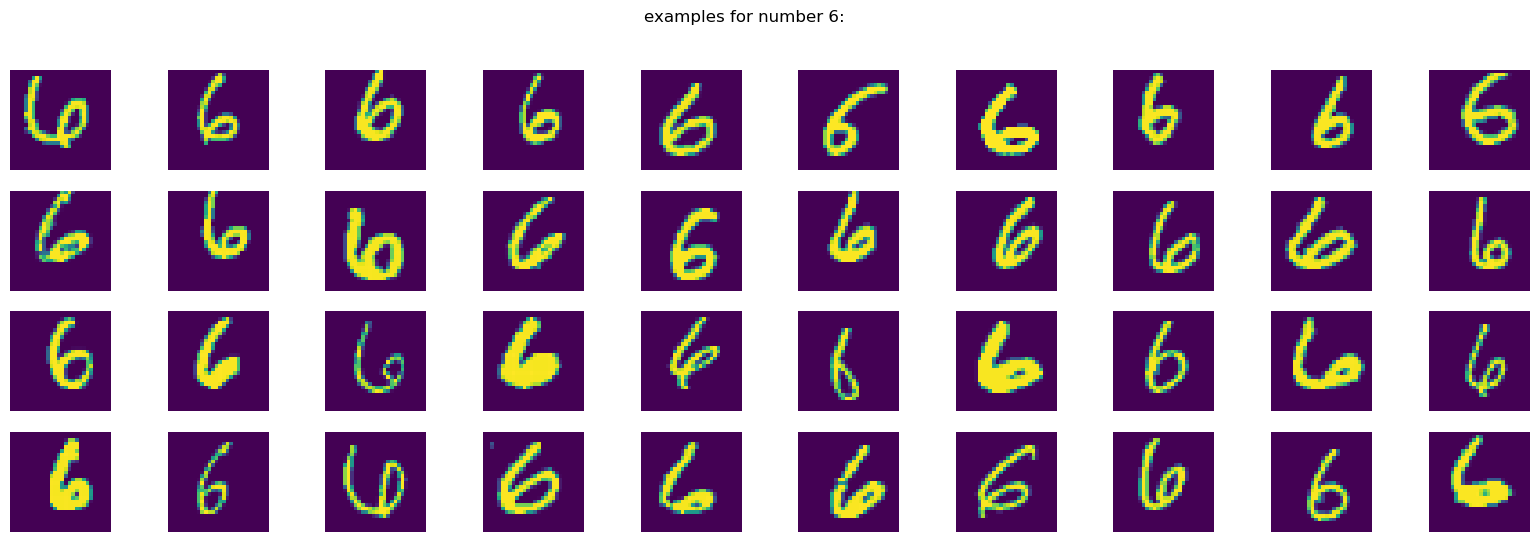

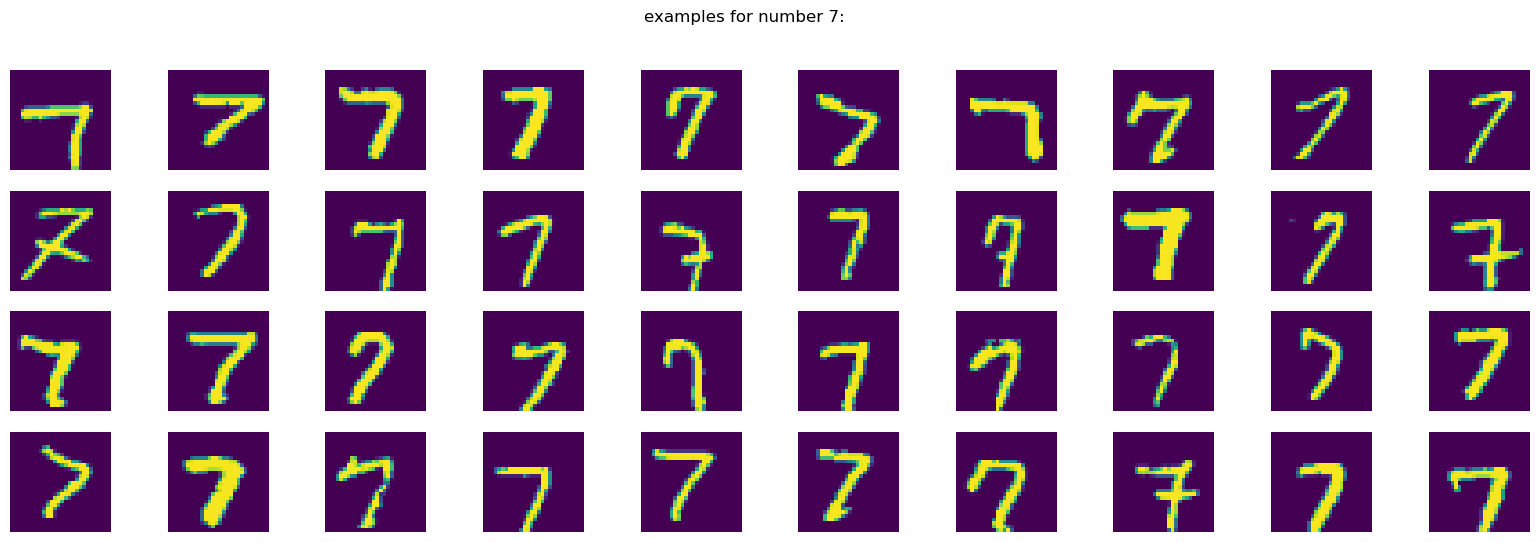

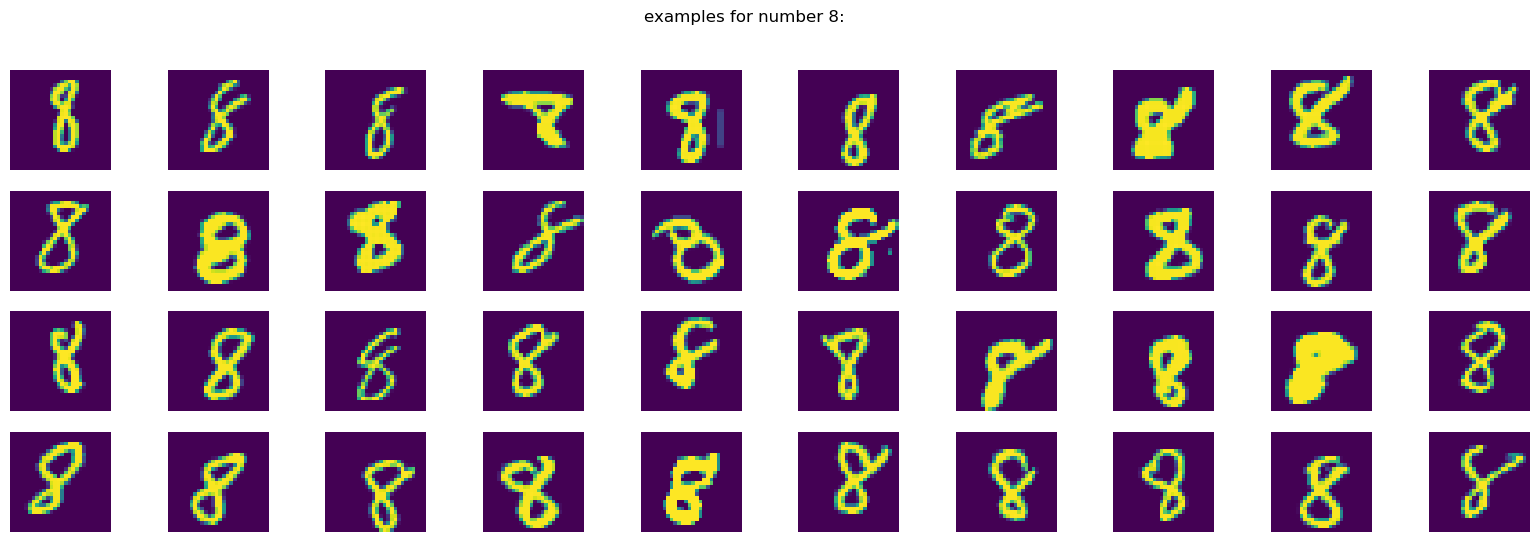

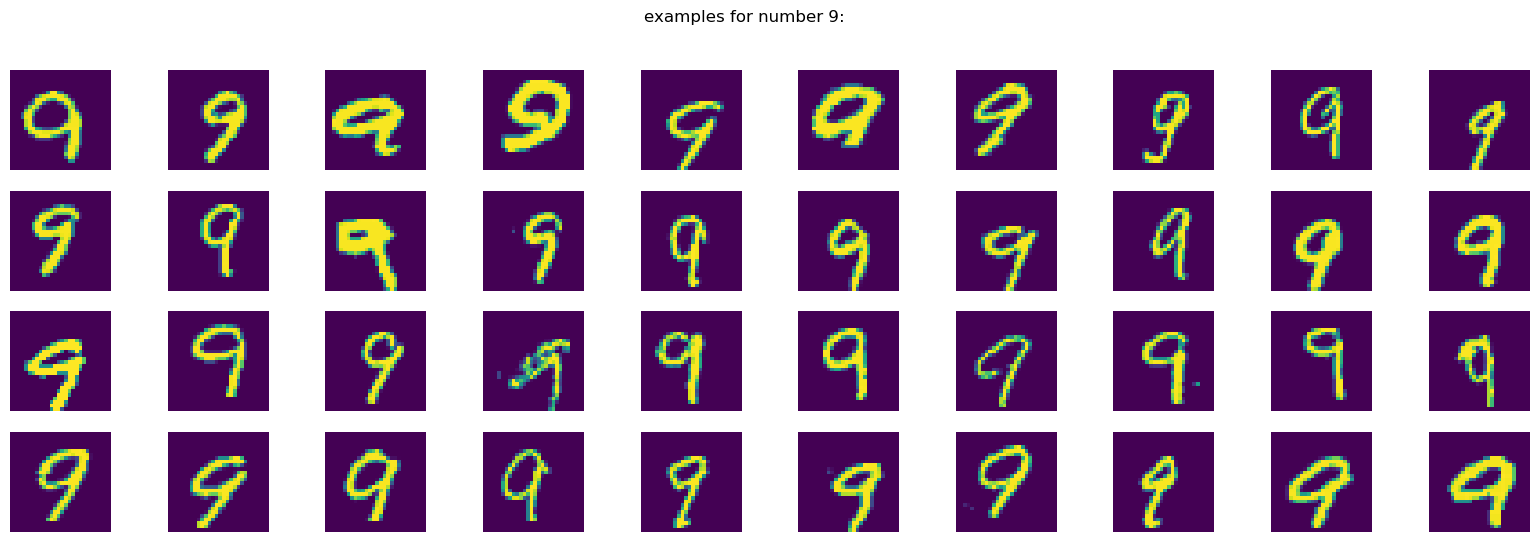

In [29]:
### -5 , 6
x_test_moved = np.zeros(x_test_img.shape)

for i in range(len(x_test_img)):
    shiftx = np.random.randint(-2, 3)
    shifty = np.random.randint(-2, 3)
    for j in range(max(0, shifty), min(28, 28 + shifty)):
        for k in range(max(0, shiftx), min(28, 28 + shiftx)):
            x_test_moved[i, j, k] = x_test_img[i, j - shifty, k - shiftx]
            
x_test_moved_flat = x_test_moved.reshape(len(x_test_moved), -1)   

plot_samples(x_test_moved,y_test)

Results __small__ shifted data:

In [30]:
evaluate_all_models("moved", x_test_moved_flat, y_test)

simple_stacking_model_moved -> Accuracy: 0.7731 | F1: 0.7713
advanced_stacking_model_moved -> Accuracy: 0.8146 | F1: 0.8134
model_simple.keras_moved -> Accuracy: 0.9031 | F1: 0.9028
model_drop.keras_moved -> Accuracy: 0.9286 | F1: 0.9285
model_drop_move.keras_moved -> Accuracy: 0.9820 | F1: 0.9820
model_drop_full.keras_moved -> Accuracy: 0.9832 | F1: 0.9832


Results __big__ shifted data:

In [31]:
evaluate_all_models("moved_big", x_test_big_moved_flat, y_test)

simple_stacking_model_moved_big -> Accuracy: 0.3225 | F1: 0.3164
advanced_stacking_model_moved_big -> Accuracy: 0.3516 | F1: 0.3457
model_simple.keras_moved_big -> Accuracy: 0.4902 | F1: 0.4835
model_drop.keras_moved_big -> Accuracy: 0.5124 | F1: 0.5113
model_drop_move.keras_moved_big -> Accuracy: 0.9653 | F1: 0.9653
model_drop_full.keras_moved_big -> Accuracy: 0.9641 | F1: 0.9641


## 6.3 Rotation:

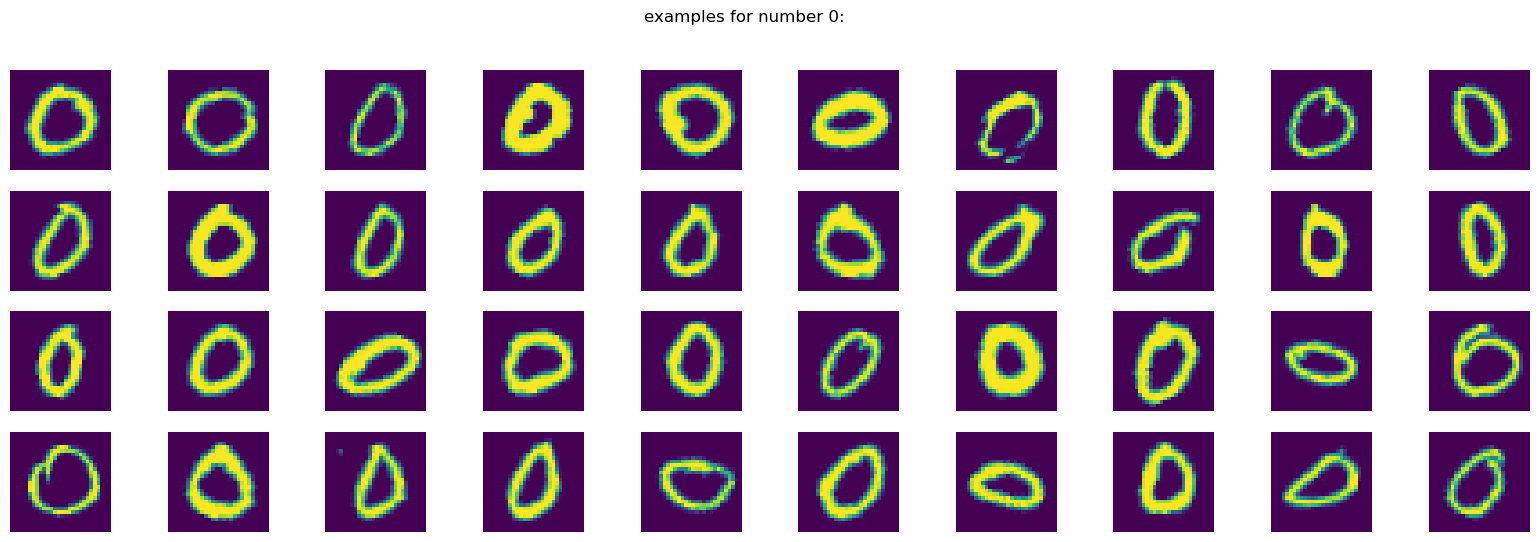

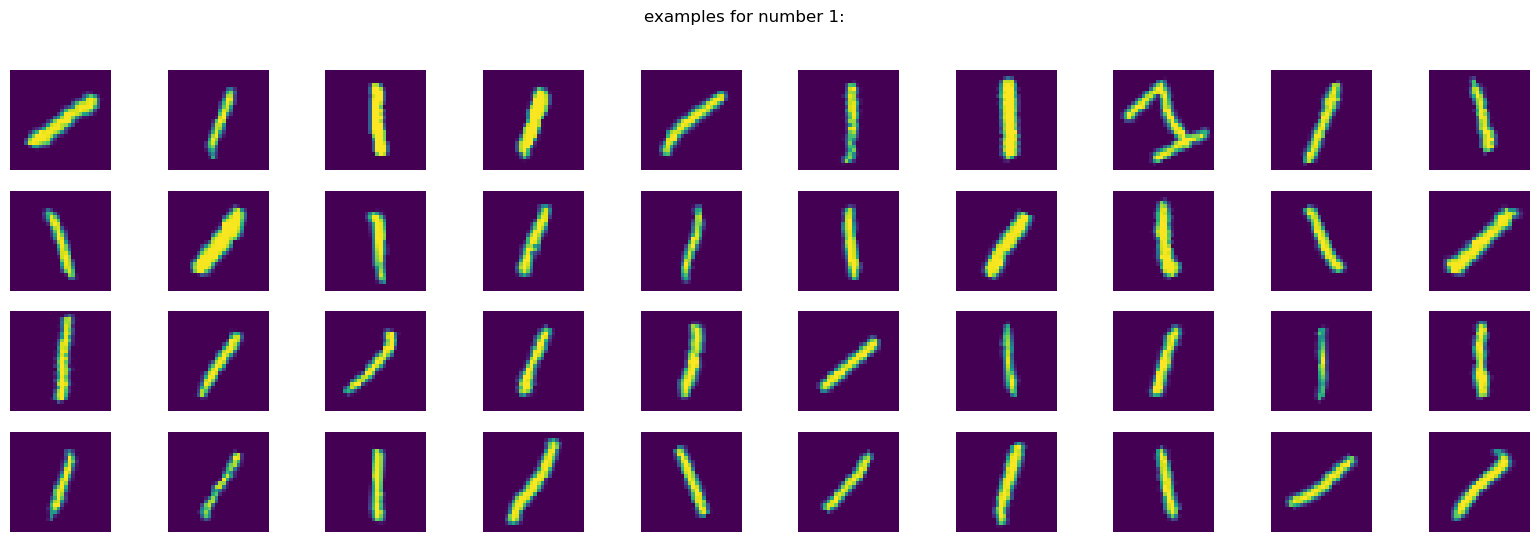

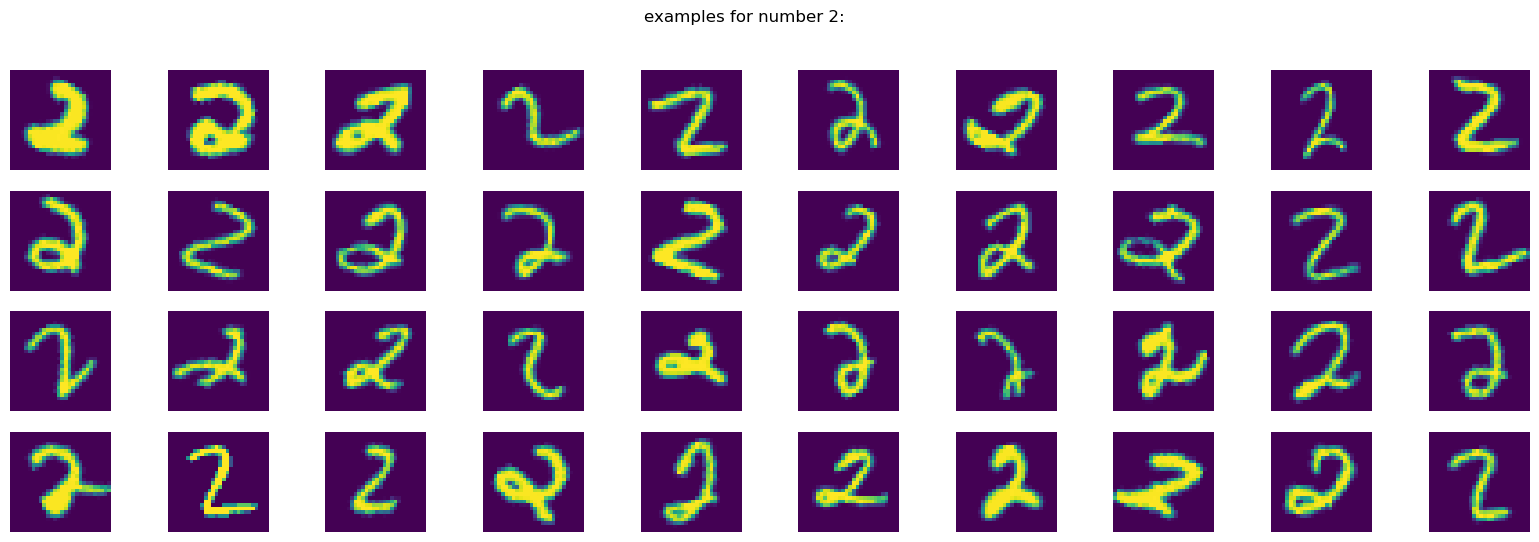

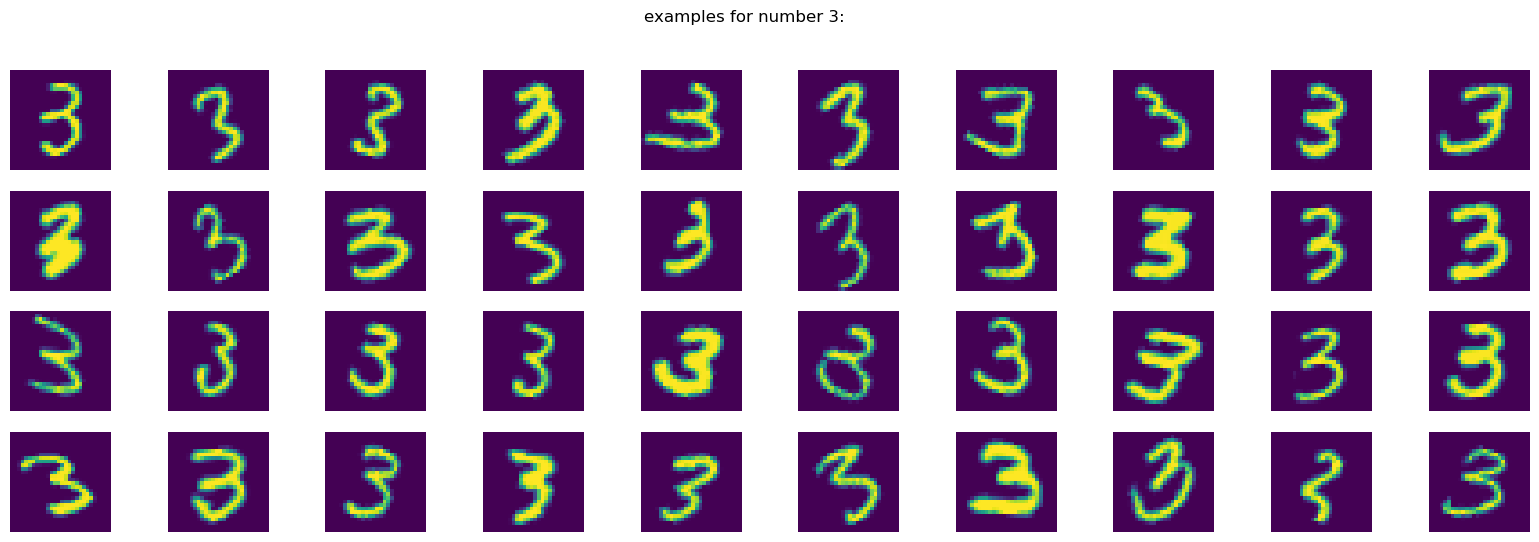

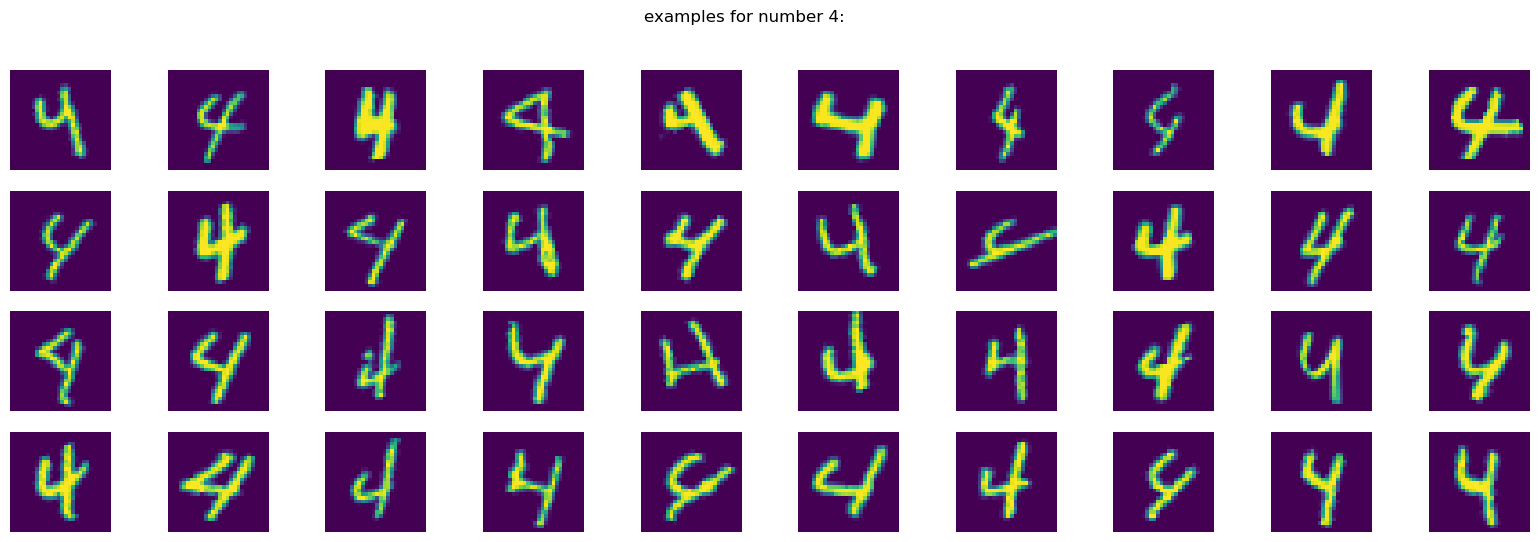

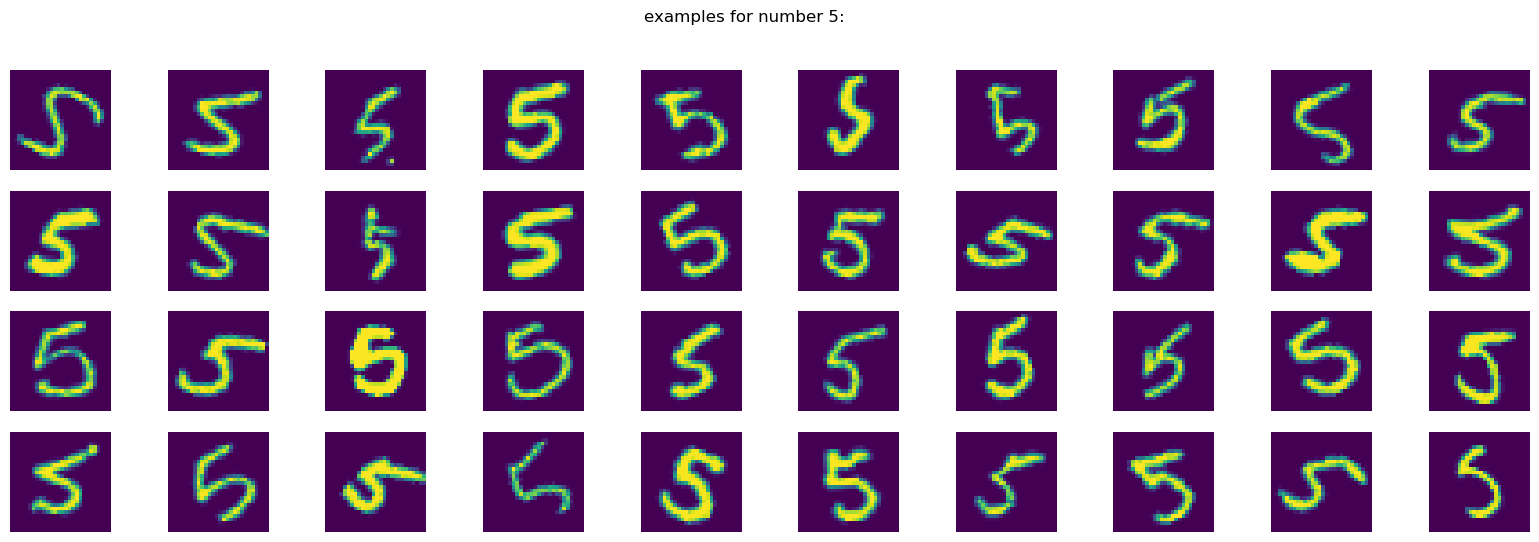

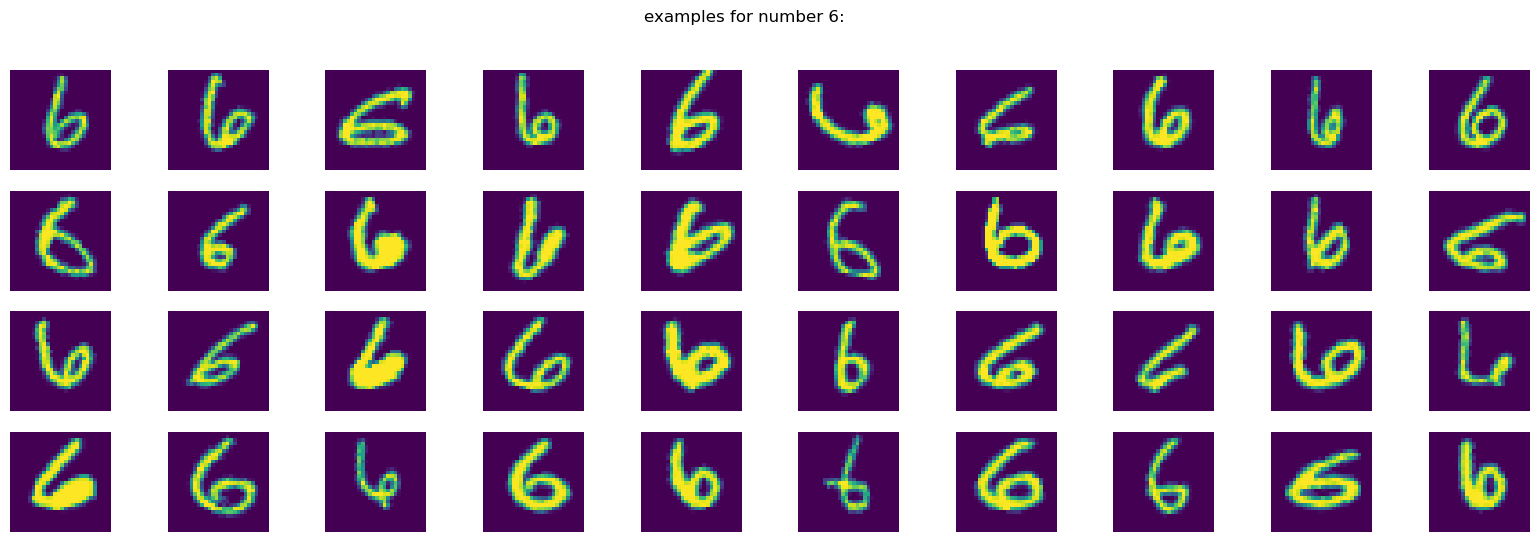

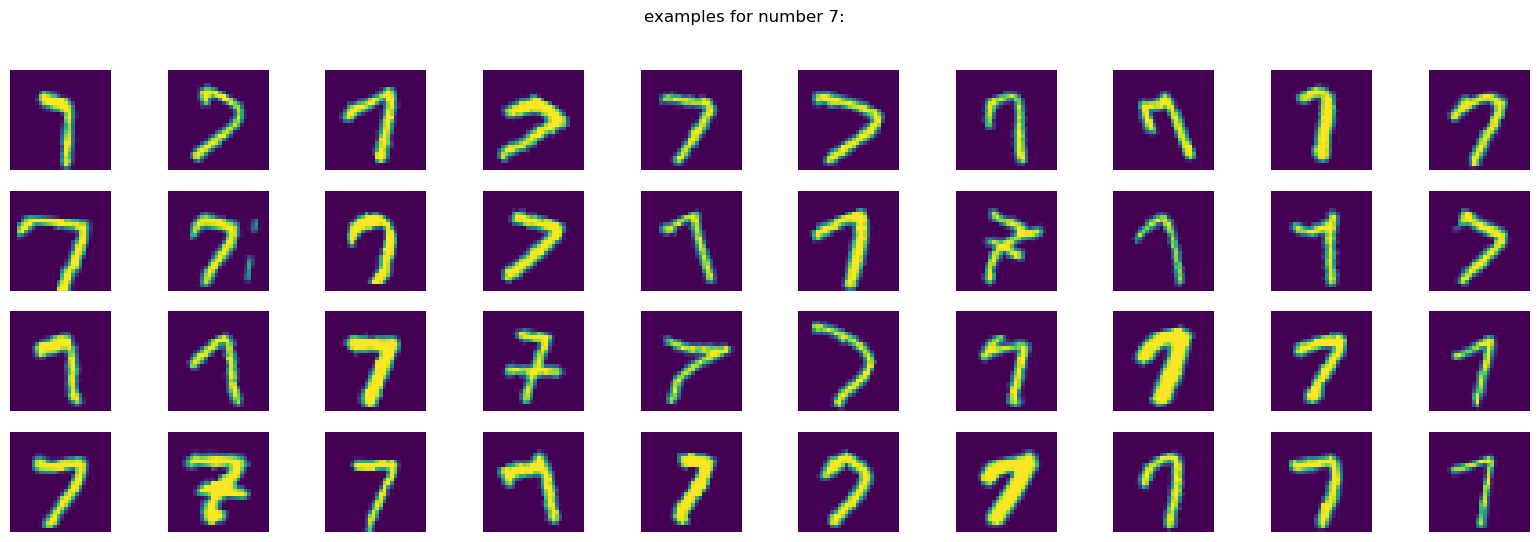

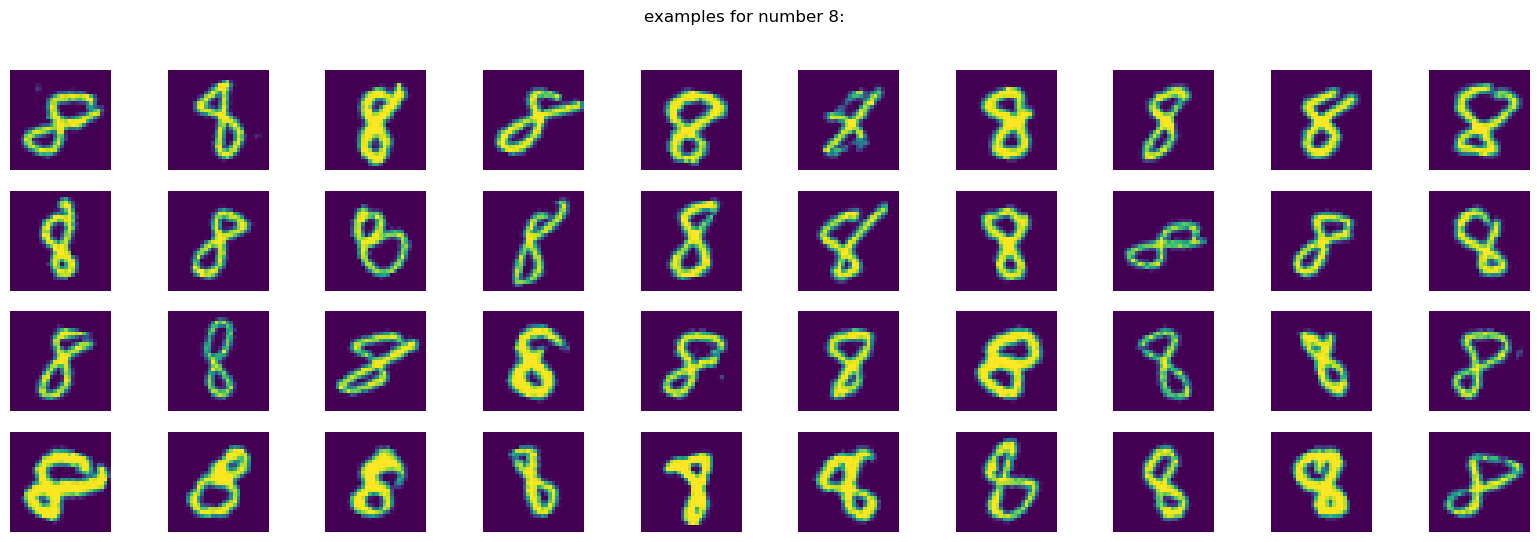

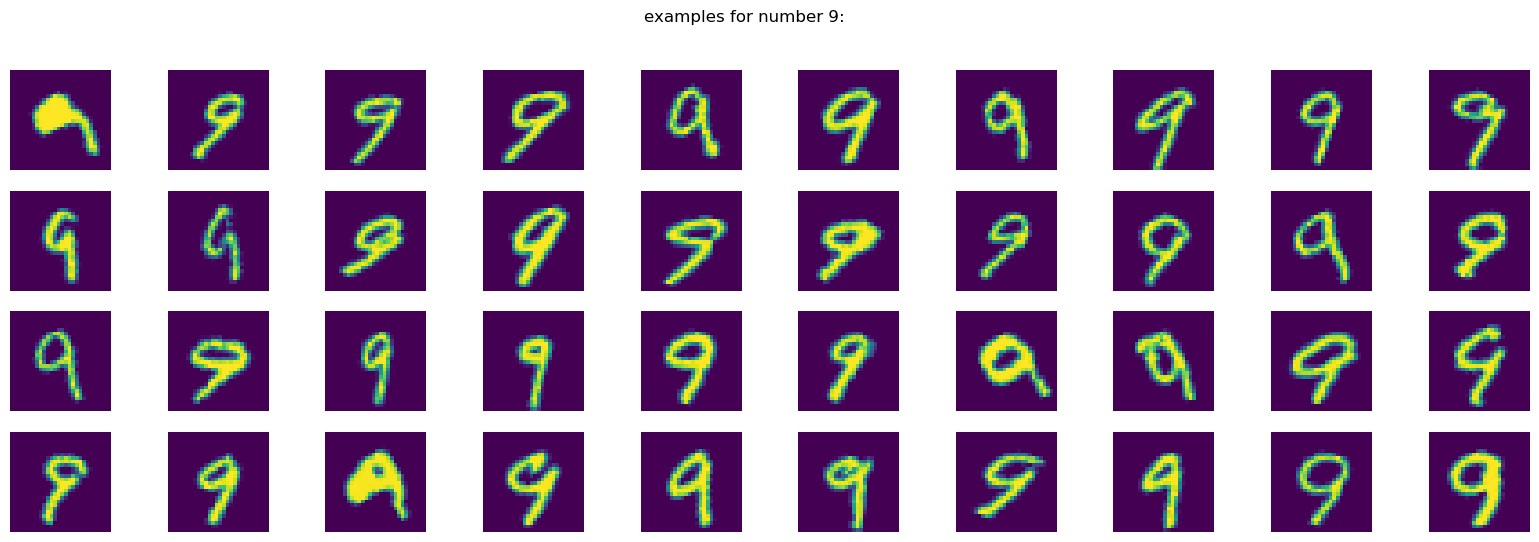

In [34]:
### We will rotate randomly betwenn -30 and 30 degrees.
x_test_rotate = np.zeros(x_test_img.shape)
for i in range(len(x_test_img)):
    x_test_rotate[i,:,:] = rotate_image(x_test_img[i], rotation_angle=np.random.randint(-30, 31))
    
x_test_rotate_flat = x_test_rotate.reshape(len(x_test_rotate), -1)    
### plot pictures
plot_samples(x_test_rotate, y_test)

__Results rotated data:__

In [35]:
evaluate_all_models("rotate", x_test_rotate_flat, y_test)

simple_stacking_model_rotate -> Accuracy: 0.9157 | F1: 0.9157
advanced_stacking_model_rotate -> Accuracy: 0.9186 | F1: 0.9190
model_simple.keras_rotate -> Accuracy: 0.9261 | F1: 0.9261
model_drop.keras_rotate -> Accuracy: 0.9439 | F1: 0.9438
model_drop_move.keras_rotate -> Accuracy: 0.9258 | F1: 0.9257
model_drop_full.keras_rotate -> Accuracy: 0.9814 | F1: 0.9814


## 6.4 Mixed (clean+ small shift+ rotated data)

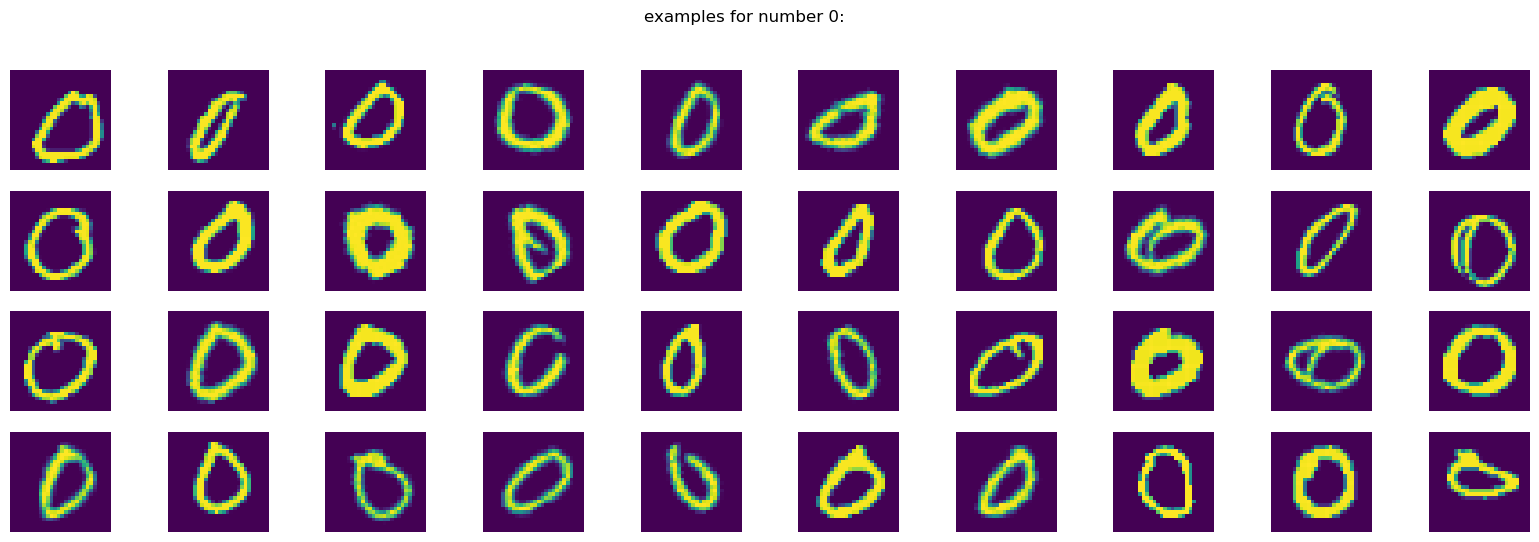

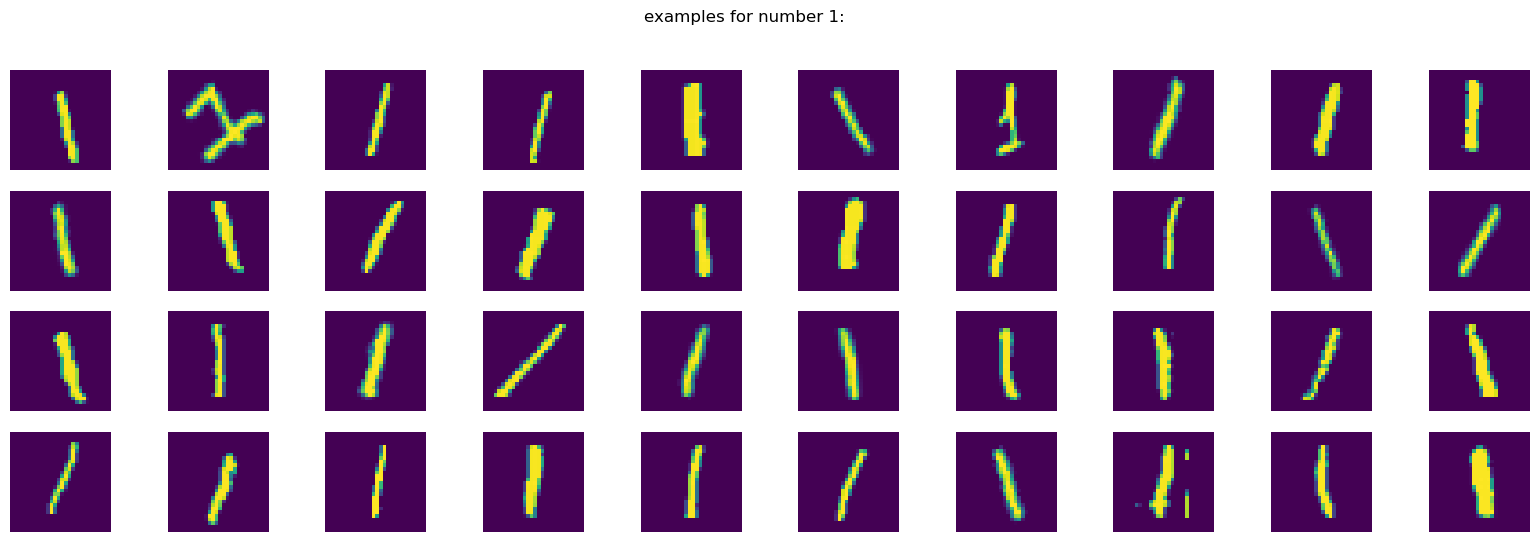

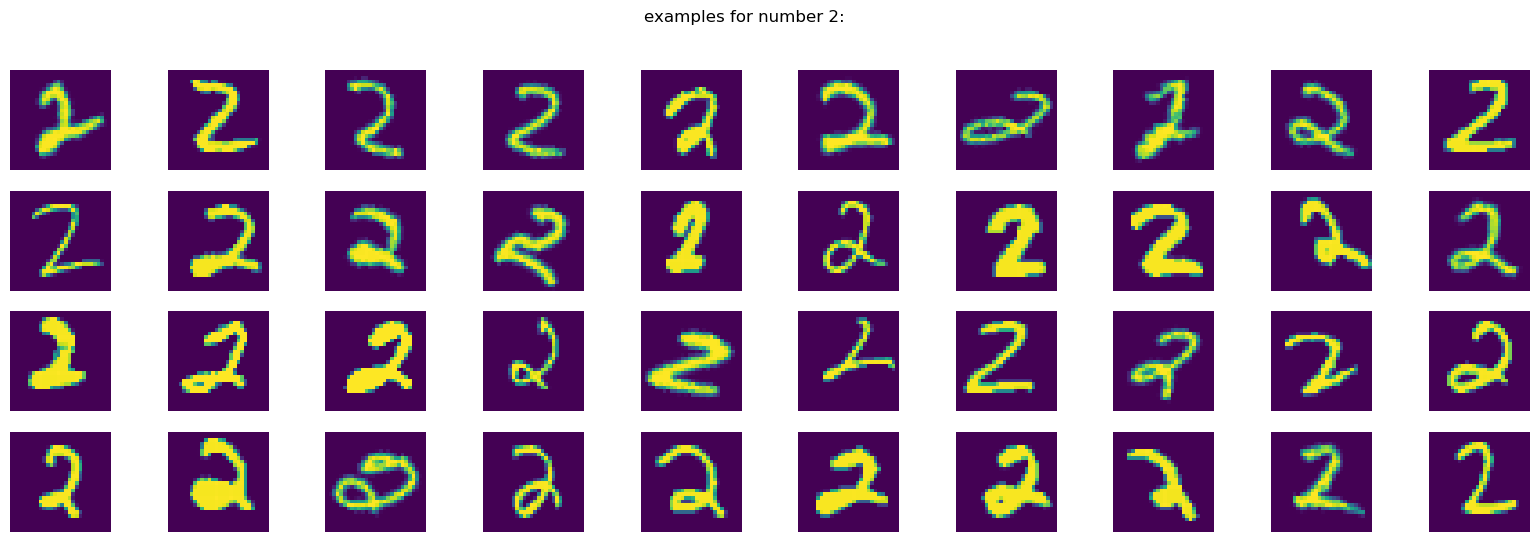

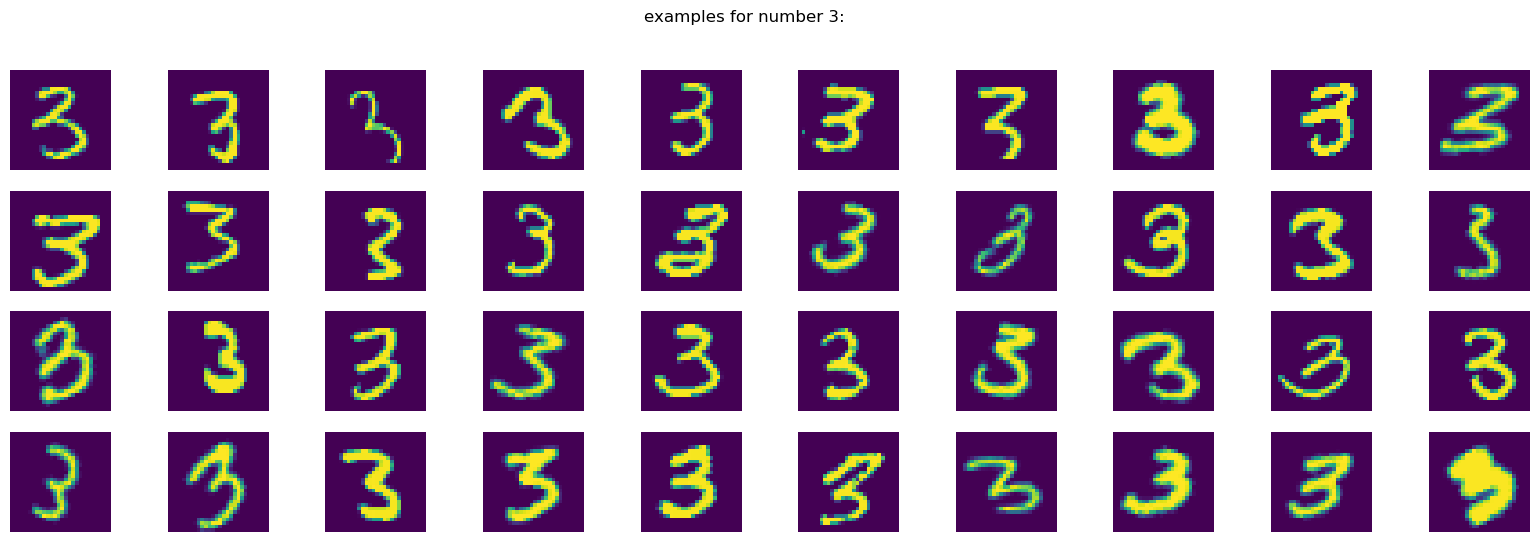

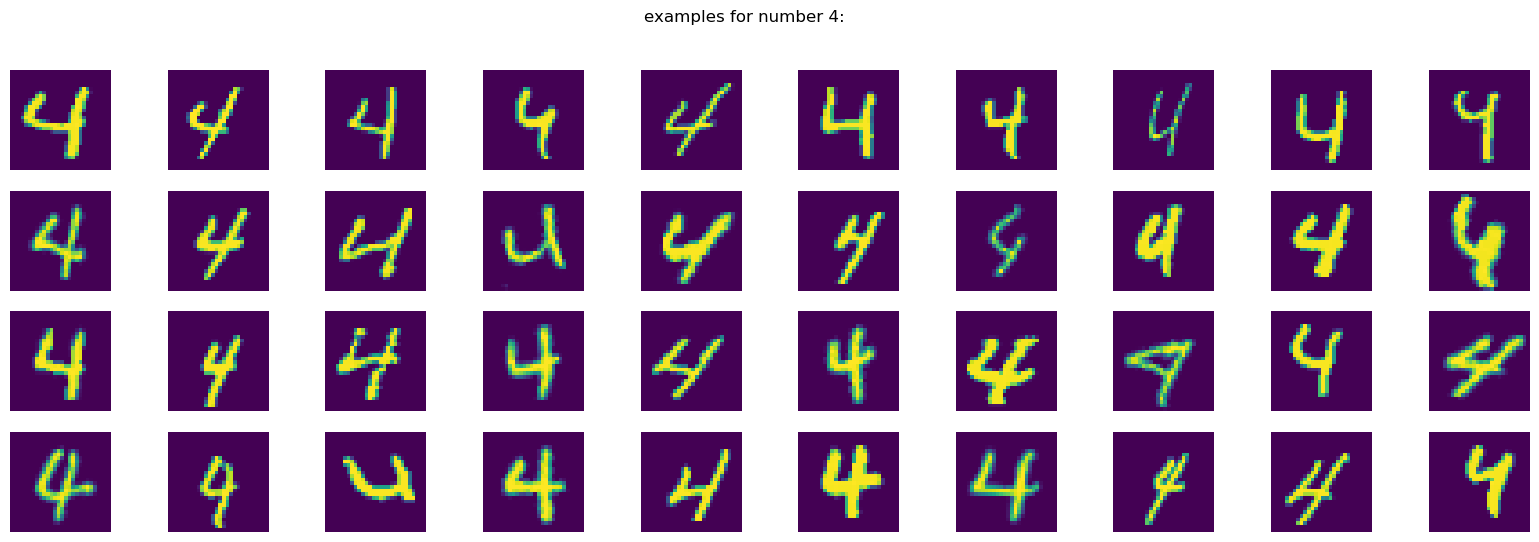

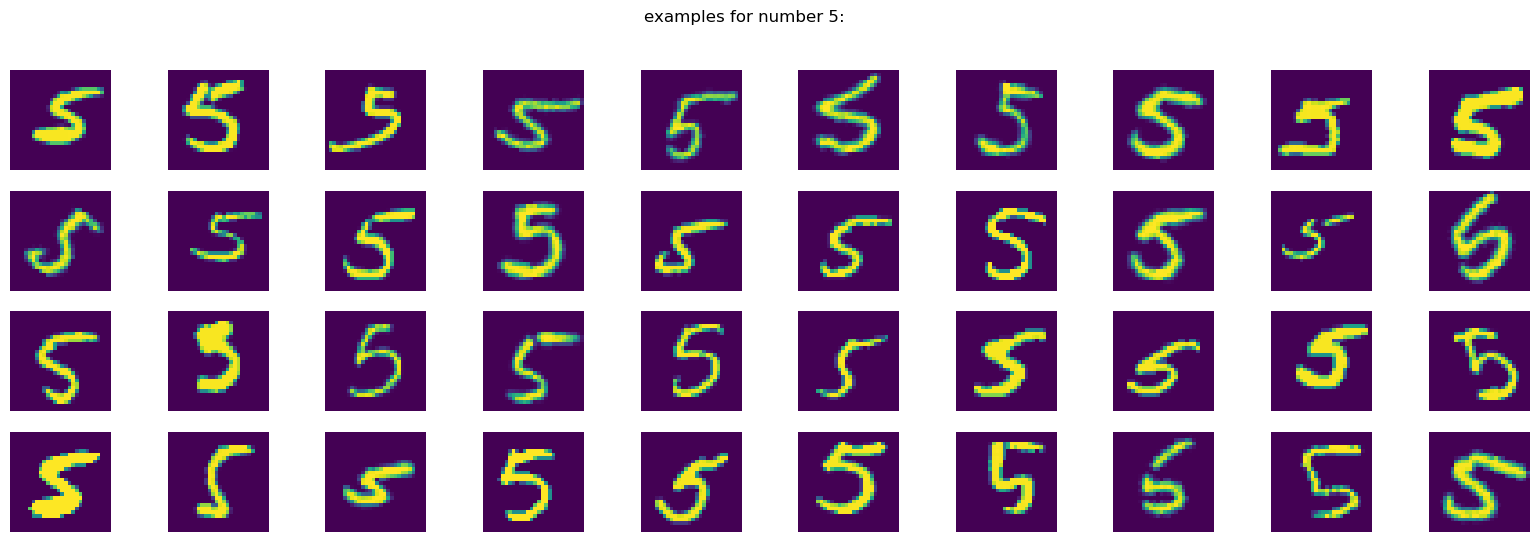

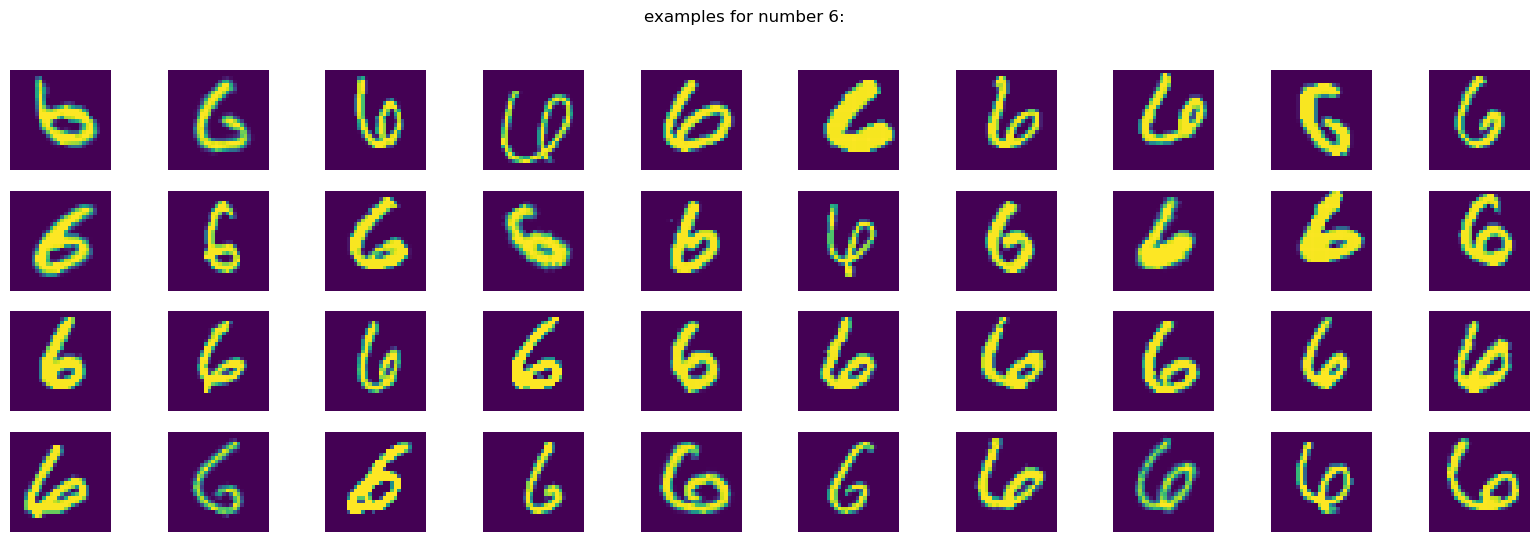

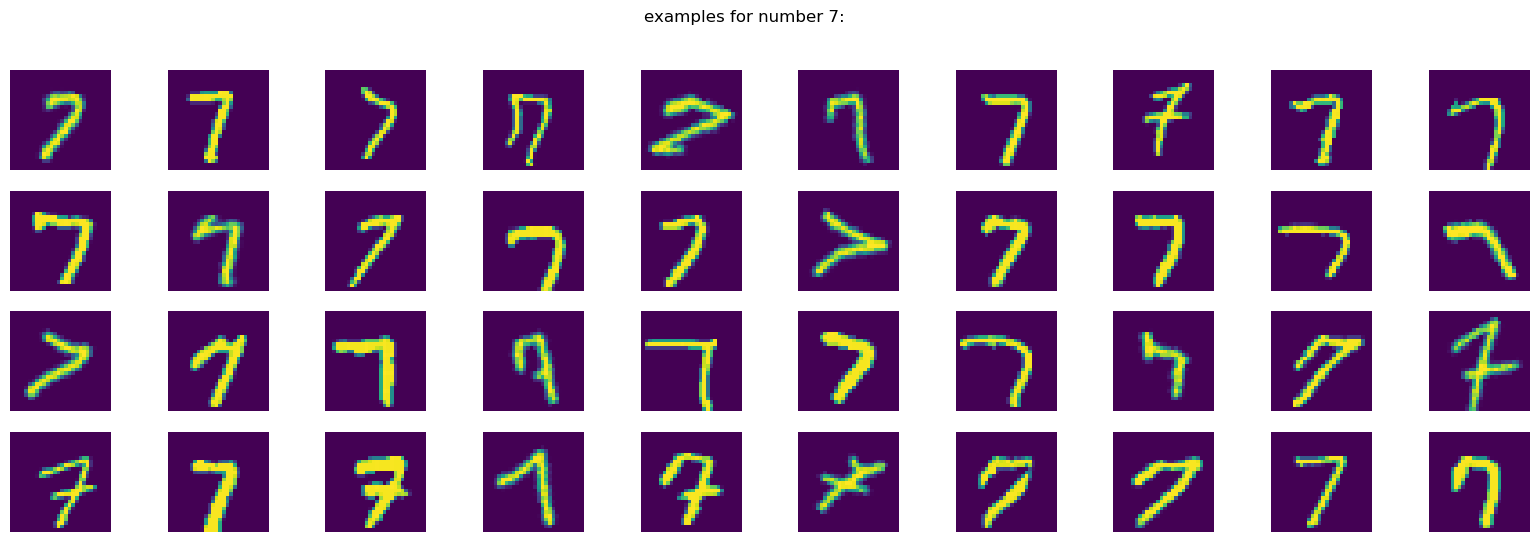

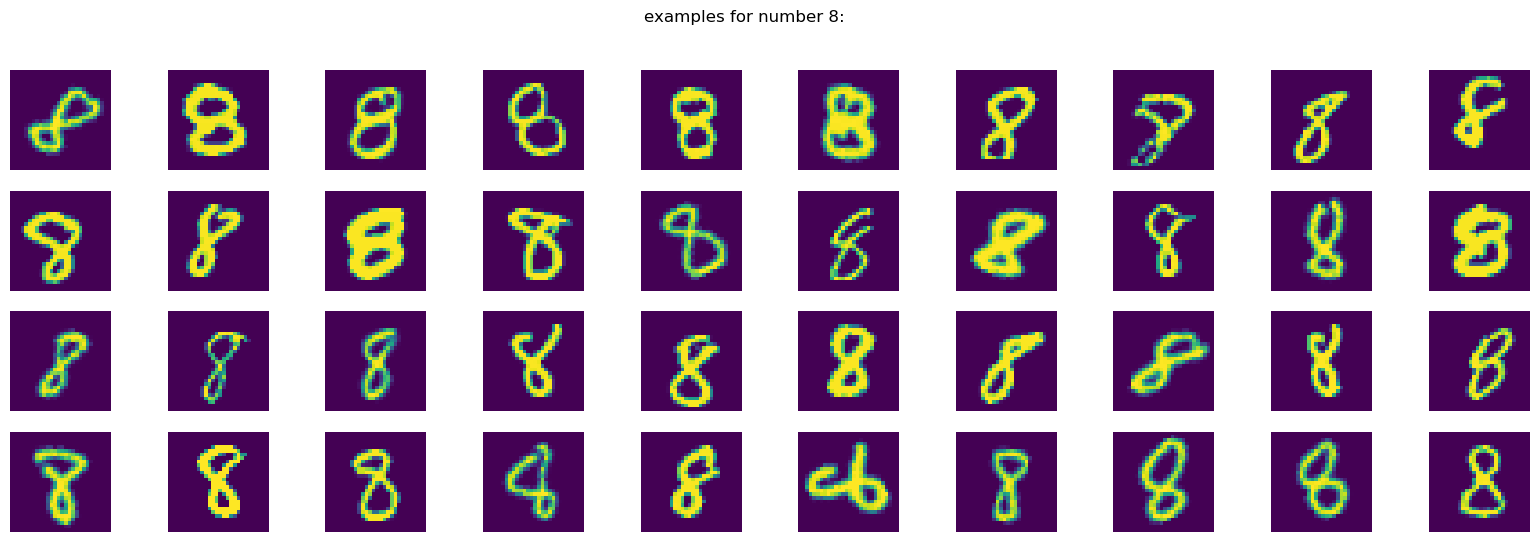

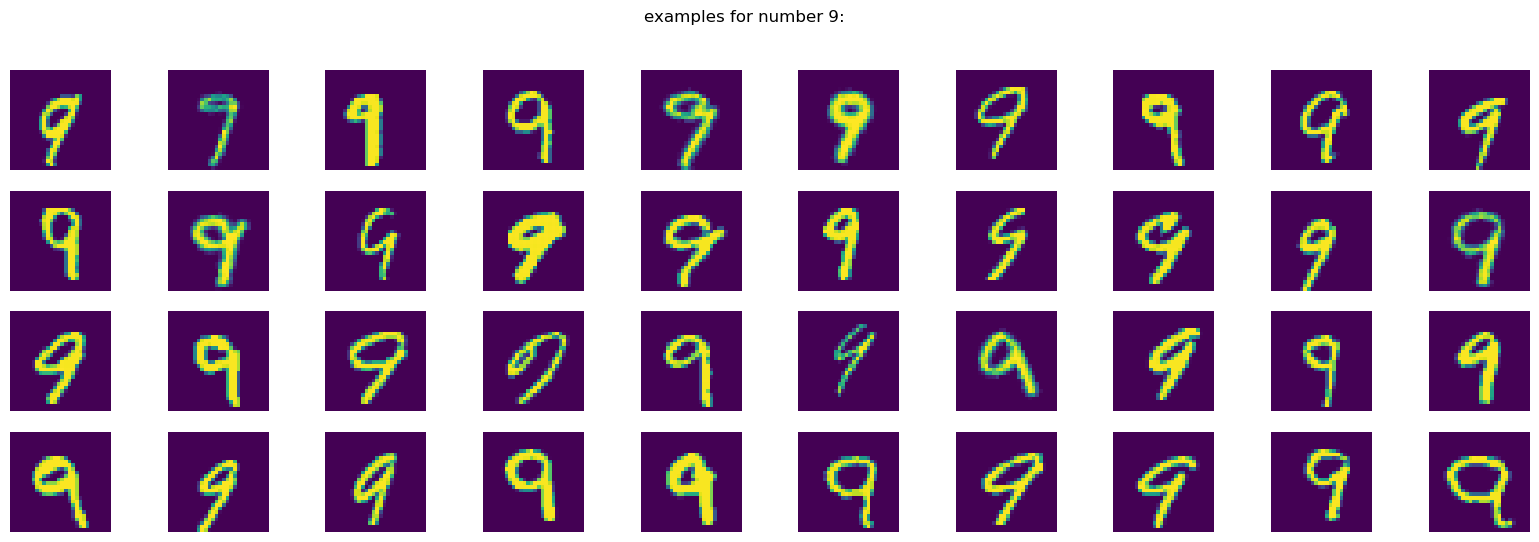

In [36]:
x_test_mixed = np.zeros_like(x_test_img)
y_test_mixed = np.array(y_test).copy()

rng = np.random.default_rng(42)

for i in range(len(x_test_img)):
    choice = rng.integers(0, 3)  # 0=clean, 1=moved, 2=rotate
    
    if choice == 0:
        x_test_mixed[i] = x_test_img[i]
    elif choice == 1:
        x_test_mixed[i] = x_test_moved[i]
    else:
        x_test_mixed[i] = x_test_rotate[i]

# Shuffle final
indices = np.arange(len(x_test_mixed))
rng.shuffle(indices)

x_test_mixed = x_test_mixed[indices]
y_test_mixed = y_test_mixed[indices]

x_test_mixed_flat = x_test_mixed.reshape(len(x_test_mixed), -1)
plot_samples(x_test_mixed, y_test_mixed)

__Results mixed data:__

In [37]:
evaluate_all_models("mix", x_test_mixed_flat, y_test_mixed)

simple_stacking_model_mix -> Accuracy: 0.8893 | F1: 0.8892
advanced_stacking_model_mix -> Accuracy: 0.9070 | F1: 0.9072
model_simple.keras_mix -> Accuracy: 0.9378 | F1: 0.9377
model_drop.keras_mix -> Accuracy: 0.9526 | F1: 0.9526
model_drop_move.keras_mix -> Accuracy: 0.9649 | F1: 0.9649
model_drop_full.keras_mix -> Accuracy: 0.9856 | F1: 0.9856


## Compare all models:

In [38]:
results = []

evaluate_all_models("clean", x_test, y_test)
evaluate_all_models("moved", x_test_moved_flat, y_test)
evaluate_all_models("moved_big", x_test_big_moved_flat, y_test)
evaluate_all_models("rotate", x_test_rotate_flat, y_test)
evaluate_all_models("mixed", x_test_mixed_flat, y_test_mixed)

simple_stacking_model_clean -> Accuracy: 0.9741 | F1: 0.9741
advanced_stacking_model_clean -> Accuracy: 0.9836 | F1: 0.9836
model_simple.keras_clean -> Accuracy: 0.9851 | F1: 0.9851
model_drop.keras_clean -> Accuracy: 0.9906 | F1: 0.9906
model_drop_move.keras_clean -> Accuracy: 0.9860 | F1: 0.9860
model_drop_full.keras_clean -> Accuracy: 0.9896 | F1: 0.9896
simple_stacking_model_moved -> Accuracy: 0.7731 | F1: 0.7713
advanced_stacking_model_moved -> Accuracy: 0.8146 | F1: 0.8134
model_simple.keras_moved -> Accuracy: 0.9031 | F1: 0.9028
model_drop.keras_moved -> Accuracy: 0.9286 | F1: 0.9285
model_drop_move.keras_moved -> Accuracy: 0.9820 | F1: 0.9820
model_drop_full.keras_moved -> Accuracy: 0.9832 | F1: 0.9832
simple_stacking_model_moved_big -> Accuracy: 0.3225 | F1: 0.3164
advanced_stacking_model_moved_big -> Accuracy: 0.3516 | F1: 0.3457
model_simple.keras_moved_big -> Accuracy: 0.4902 | F1: 0.4835
model_drop.keras_moved_big -> Accuracy: 0.5124 | F1: 0.5113
model_drop_move.keras_move

Save the results (__already done__)

In [40]:
#os.makedirs("../results", exist_ok=True)

#with open("../results/01_robustness.json", "w") as f:
#    json.dump(results, f, indent=2)

#print("Results saved in ../results/01_robustness.json")

Results saved in ../results/01_robustness.json


Load the results:

In [42]:
with open("../results/01_robustness.json", "r") as f:
    rob_results = json.load(f)

results_df = pd.DataFrame(rob_results)

In [43]:
results_df = pd.DataFrame(results)

clean_df = results_df[results_df["model"].str.endswith("_clean")].sort_values(by="accuracy", ascending=False)
moved_df = results_df[results_df["model"].str.endswith("_moved")].sort_values(by="accuracy", ascending=False)
big_moved_df = results_df[results_df["model"].str.endswith("_big")].sort_values(by="accuracy", ascending=False)
rotate_df = results_df[results_df["model"].str.endswith("_rotate")].sort_values(by="accuracy", ascending=False)
mixed_df = results_df[results_df["model"].str.endswith("_mixed")].sort_values(by="accuracy", ascending=False)

print("CLEAN")
display(clean_df)

print("MOVED")
display(moved_df)

print("BIG MOVED")
display(big_moved_df)

print("ROTATE")
display(rotate_df)

print("MIXED")
display(mixed_df)

CLEAN


,model,accuracy,f1_weighted
3,model_drop.keras_clean,0.9906,0.990601
5,model_drop_full.keras_clean,0.9896,0.989598
4,model_drop_move.keras_clean,0.9860,0.986001
2,model_simple.keras_clean,0.9851,0.985085
1,advanced_stacking_model_clean,0.9836,0.983592
0,simple_stacking_model_clean,0.9741,0.974070


MOVED


,model,accuracy,f1_weighted
11,model_drop_full.keras_moved,0.9832,0.983200
10,model_drop_move.keras_moved,0.9820,0.981993
9,model_drop.keras_moved,0.9286,0.928533
8,model_simple.keras_moved,0.9031,0.902803
7,advanced_stacking_model_moved,0.8146,0.813436
6,simple_stacking_model_moved,0.7731,0.771265


BIG MOVED


,model,accuracy,f1_weighted
16,model_drop_move.keras_moved_big,0.9653,0.965313
17,model_drop_full.keras_moved_big,0.9641,0.964148
15,model_drop.keras_moved_big,0.5124,0.511333
14,model_simple.keras_moved_big,0.4902,0.483450
13,advanced_stacking_model_moved_big,0.3516,0.345731
12,simple_stacking_model_moved_big,0.3225,0.316410


ROTATE


,model,accuracy,f1_weighted
23,model_drop_full.keras_rotate,0.9814,0.981388
21,model_drop.keras_rotate,0.9439,0.943835
20,model_simple.keras_rotate,0.9261,0.926137
22,model_drop_move.keras_rotate,0.9258,0.925729
19,advanced_stacking_model_rotate,0.9186,0.919010
18,simple_stacking_model_rotate,0.9157,0.915650


MIXED


,model,accuracy,f1_weighted
29,model_drop_full.keras_mixed,0.9856,0.985600
28,model_drop_move.keras_mixed,0.9649,0.964881
27,model_drop.keras_mixed,0.9526,0.952603
26,model_simple.keras_mixed,0.9378,0.937673
25,advanced_stacking_model_mixed,0.9070,0.907155
24,simple_stacking_model_mixed,0.8893,0.889158
